# Домашнее задание 1.: Градиентный спуск и основы PyTorch

### Общая информация
Цели работы:
1. Повторим базу и напишем своими руками gradient descent
2. Познакомимся с основами PyTorch и напишем свой класс

Полезные материалы: будут сопровождать вас по ходу работы.

# Часть 1. Градиентный спуск (5 баллов)

В этом задании две части $-$ теоретическая и практическая. Теорию можно набирать, используя LaTex, или просто решать на листочке, сфотографировать и отправить вместе с заполненным ноутбуком.

## Теория (1 балл)

**Напоминание**: градиентный спуск — метод оптимизации, основанный на том, что отрицательный градиент указывает направление наибольшего убывания функции. Для функции $f(x)$ одношаговый градиентный спуск выглядит как:

$$x_{t+1} = x_t - \eta \nabla f(x_t)$$

Где $\eta$ — learning rate (шаг). Для многомерных функций аналогично.

**Полезные ссылки:**

- Bishop, "Pattern Recognition and Machine Learning" (глава о оптимизации).
- Краткое руководство: https://ml-cheatsheet.ru/gradient-descent/
- Официальный tutorial по оптимизации: https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html


### **Задание 1** (0.4 балла)
* Найдите экстремумы следующих функций (вручную, где возможно) и укажите их тип (максимум, минимум);
* Найдите точки перегиба функций (вручную, где возможно)

1) $f(x) = x^2 - 30x + 1$

2) $g(x) = -x^3 + 5x - 7x^2 + 17$

3) $h(x) = x^2 - 1/x$

4) $j(x) = 1/x^5 + x^{17} + 8$

---

**Краткая справка: экстремумы и перегибы**

**Экстремумы (локальные максимумы и минимумы).**

Точка $x_0$ называется *критической*, если первая производная в ней равна нулю $f'(x_0) = 0$. Для функций нескольких переменных это точки, где все частные производные равны нулю.

Критические точки являются кандидатами на локальные экстремумы, но это не все такие точки:

- Если $f'(x_0) = 0$ и $f''(x_0) > 0$, то в $x_0$ — **локальный минимум**.  
- Если $f'(x_0) = 0$ и $f''(x_0) < 0$, то в $x_0$ — **локальный максимум**.  
- Если $f'(x_0) = 0$ и $f''(x_0) = 0$, требуется дополнительный анализ (возможно, **седловая точка** - является одновременно точкой локального максимума по одному направлению и точкой локального минимума по другому направлению).

> Соответственно, алгоритм поиска локальных экстремумов: ищем производную функции -> приравниваем к нулю, решаем уравнение и получаем критические точки -> проверяем знак производной (от этого зависит max/min) или используем вторую производную для проверки (если равно 0, нужно доп. исследование)

---

**Перегиб**

Пусть $a < b < c$. Пусть на промежутке $a < b$ функция $f$ выпукла, а на промежутке $b < c$ функция $f$ вогнута. Тогда точка $b$ называется **точкой перегиба** (то есть функция меняет знак выпуклости в этой точке). Пример: точка 0 является точкой перегиба для функции $f(x) = x^3$.

Необходимое условие точки перегиба для дважды дифференцируемой функции: $f′′(c) = 0$

То есть практически ищут точки, где $f''(x_0) = 0$, и проверяют изменение знака $f''$ по обе стороны от этой точки.  
Если знак действительно меняется, то в $x_0$ находится точка перегиба.


> Соответственно, алгоритм поиска точек перегиба: ищем вторую производную -> приравнимаем нулю и решаем уравнение (либо получаем точки, где она не существует) -> проверяем смену знака


---

**Ваше решение:**

1. Для нахождения критических точек функции $f(x) = x^2 - 30x + 1$ вычислим ее первую производную и приравняем полученное выражение к нулю. Корни полученного уравнения и будут искомыми критическими точками.

$f'(x) = (x^2)' - (30x)' + (1)'= 2x - 30 $;

$2x - 30 = 0$;

**$x = 15$ - критическая точка**.

Вычислим вторую производную функции $f(x) = x^2 - 30x + 1$ и найдем ее знак в найденной критической точке.

$f''(x) = (2x - 30)'= 2. $

Так как вторая производная функции $f(x)$ является положительной константой $(2>0)$, то на всей области определения функции $f(x)$ она не имеет нулевых значений, а значит функция **$f(x)$ не имеет точек перегиба**.  

Также $f''(x)$  положительна и в найденной критической точке, а значит $x = 15$ - точка локального минимума. А так как данная функция является непрерывной на всей своей области определения, не имеет точек перегиба и найденная точка является единственной точкой экстремума, то **$x = 15$** **является и глобальным минимумом функции**.


2. Для нахождения критических точек функции $g(x) = - x^3 + 5x - 7x^2 + 17$ вычислим ее первую производную и приравняем полученное выражение к нулю. Корни полученного уравнения и будут искомыми критическими точками.

$g'(x) = (-x^3)' - (7x^2)' + (5x)' + (17)'= -3x^2 - 14x + 5 $;

$-3x^2 - 14x + 5 = 0$;

Найдем корни полученного квадратного уравнения.

$D = (-14)^2 - 4\cdot \ (-3)\cdot 5 = 196 + 60 = 256;$

$x_{1,2} = \dfrac{14 \pm \sqrt{256}}{-6}$;

$x_1 = -\dfrac{14 + 16}{6}, x_2 = -\dfrac{14 - 16}{6};$

$x_1 = -5$,  $x_2 = \dfrac{1}{3}$ - критические точки.

Вычислим вторую производную функции $g(x) = - x^3 - 7x^2 + 5x  + 17$, и найдем ее знаки в найденных критических точках.

$g''(x) = (-3x^2 - 14x + 5)'= -6x - 14; $

$g''(-5) = 30 - 14 = 16 > 0$ - **в точке**  **$x_1 = -5$  функция $g(x)$ имеет локальный минимум**;

$g''\left(\dfrac{1}{3}\right) = -2 - 14 = -16 < 0$ - **в точке  $x_2 = \dfrac{1}{3} \approx 0,33 $  функция $g(x)$ имеет локальный максимум**.

Для нахождения точек перегиба приравняем вторую производную функции $g(x)$ к нулю и найдем корни полученного уравнения:

$-6x - 14 = 0; $

$x = -\dfrac{14}{6} = -2\dfrac{1}{3} \approx -2,33$;

При значениях $x < -2\dfrac{1}{3}$ значения $g''(x)$ будут больше $0$, а при значениях $x > -2\dfrac{1}{3}$ - меньше $0$, значит **в точке $x = -2\dfrac{1}{3} \approx -2,33$ функция $g(x)$ имеет точку перегиба**.

3. Для нахождения критических точек функции $h(x) = x^2 - \dfrac{1}{x}$ вычислим ее первую производную и приравняем полученное выражение к нулю. Корни полученного уравнения и будут искомыми критическими точками.

Следует отметить, что область определения данной функции равна:

$D(x) =  (-\infty, 0)\cup(0, +\infty)$, т.е. в точке $x = 0$ функция имеет разрыв.



$h'(x) = (x^2)' - \left(\dfrac{1}{x}\right)' = 2x + \dfrac{1}{x^2}$;

$2x + \dfrac{1}{x^2} = \dfrac{2x^3 + 1}{x^2} = 0$ при $х\neq0$;

$2x^3 + 1 = 0$;

$x^3 = - \dfrac{1}{2}$;

**$x = - \dfrac{1}{\sqrt[3]{2}} \approx -0,79$ - критическая точка.**

Вычислим вторую производную функции $h(x) = x^2 - \dfrac{1}{x}$, и найдем ее знак в найденной критической точке.

$h''(x) = \left(2x + \dfrac{1}{x^2}\right)'= 2 - \dfrac{2}{x^3}; $

$h''\left(- \dfrac{1}{\sqrt[3]{2}}\right) = \left(2 - \dfrac{2}{\left(- \dfrac{1}{\sqrt[3]{2}}\right)^3}\right) = 2 - \dfrac{2}{\left(- \dfrac{1}{2}\right)} = 2 + 2\cdot2 = 6 > 0$ - **в точке**  **$x = - \dfrac{1}{\sqrt[3]{2}} \approx -0,79$  функция $h(x)$ имеет локальный минимум**.

Для нахождения точек перегиба приравняем вторую производную функции $h(x)$ к нулю и найдем корни полученного уравнения:

$2 - \dfrac{2}{x^3} = \dfrac{2x^3 - 2}{x^3} = 0$ при $х\neq0$;

$2x^3 - 2 = 0$;

$x^3 = 1$;

$x = 1$;

При значениях $x < 0$ значения $h''(x)$ будут больше $0$, при $0< x < 1$ значения $h''(x)$ будут меньше $0$, а при значениях $x > 1$ - снова больше $0$. В точке $х = 0$ функция  $h(x)$ имеет разрыв, а **в точке $x = 1$ функция $h(x)$ имеет точку перегиба**.

4. Для нахождения критических точек функции $j(x) = \dfrac{1}{x^5} + x^{17} + 8 $ вычислим ее первую производную и приравняем полученное выражение к нулю. Корни полученного уравнения и будут искомыми критическими точками.

Следует отметить, что область определения данной функции равна:

$D(x) =  (-\infty, 0)\cup(0, +\infty)$, т.е. в точке $x = 0$ функция имеет разрыв.


$j'(x) = \left(\dfrac{1}{x^5}\right)'+ (x^{17})' + (8)' = - \left(\dfrac{5}{x^6}\right) + 17x^{16}$;

$- \left(\dfrac{5}{x^6}\right) + 17x^{16} = \dfrac{-5+17x^{22}}{x^6} = 0$ при $х\neq0$;

$17x^{22} - 5 = 0$;

$x^{22} = \dfrac{5}{17}$;

**$x_{1,2} = \pm\sqrt[22]{\dfrac{5}{17}}$ - критические точки.**

Вычислим вторую производную функции $j(x) = \dfrac{1}{x^5} + x^{17} + 8$, и найдем ее знак в найденной критической точке.

$j''(x) = \left(- \left(\dfrac{5}{x^6}\right) + 17x^{16}\right)'= \dfrac{30}{x^7}+ 272x^{15}; $

$j''\left(\sqrt[22]{\dfrac{5}{17}}\right)= \dfrac{30}{\left(\sqrt[22]{\dfrac{5}{17}}\right)^7}+ 272\left(\sqrt[22]{\dfrac{5}{17}}\right)^{15} > 0$ - **в точке**  **$x_1 = \sqrt[22]{\dfrac{5}{17}}$  функция $j(x)$ имеет локальный минимум**;

$j''\left(-\sqrt[22]{\dfrac{5}{17}}\right)= -\dfrac{30}{\left(\sqrt[22]{\dfrac{5}{17}}\right)^7}- 272\left(\sqrt[22]{\dfrac{5}{17}}\right)^{15} < 0$ - **в точке**  **$x_2 = -\sqrt[22]{\dfrac{5}{17}}$  функция $j(x)$ имеет локальный максимум**.

Для нахождения точек перегиба приравняем вторую производную функции $j(x)$ к нулю и найдем корни полученного уравнения:

$\dfrac{30}{x^7}+ 272x^{15} = \dfrac{30 + 272x^{22}}{x^7} = 0$ при $х\neq0$;

$30 + 272x^{22} = 0$;

$x^{22} = -\dfrac{30}{272}$ - у данного уравнения нет корней, следовательно, функция **$j(x)$ не имеет точек перегиба в своей области определения.**

### **Задание 2** (0.4 балла)
Найдите экстремумы и точки перегиба этих функций в Python.

*Справка*:
> Sympy $-$ бибилиотека для символьных вычислений (математика "на бумаге", но в коде). Умеет в производные, интегралы, пределы, уравнения, матрицы, многочлены и т.д.

Пример запуска (функция $f(x) = x^2$):

In [1]:
import sympy as sp

# объявляем переменную
x = sp.Symbol('x')

# задаём функцию
f = x**2

# производная
f_prime = sp.diff(f, x)

# выводим результаты
print("f(x) =", f)
print("f'(x) =", f_prime)

f(x) = x**2
f'(x) = 2*x


Теперь переходим к решению ранее озвученного задания

In [ ]:
%pip install numpy matplotlib sympy tqdm


In [2]:
import sympy as sp
import numpy as np
from enum import Enum

# your code here

from sympy import symbols, diff, Eq, solve
from sympy import lambdify

# объявляем переменную
x = sp.Symbol('x', real=True)

import random
import matplotlib.pyplot as plt

1. $f(x) = x^2 - 30x + 1$

In [ ]:
# задаём функцию
f = x**2 - 30*x + 1

# первая производная
f_prime = sp.diff(f, x)

#найдем критические точки функции как корни уравнения f_prime = 0
roots_algebraic_f = solve(Eq(f_prime, 0), x)

# вторая производная
f_prime_2 = sp.diff(f, x, 2)

#найдем возможные точки перегиба как корни уравнения f_prime_2 = 0
roots_algebraic_f_2 = solve(Eq(f_prime_2, 0), x)

# выводим результаты
print("Начальная функция f(x) =", f)
print("Первая производная f'(x) =", f_prime)
print("Вторая производная f''(x) =", f_prime_2)
print("Критические точки - корни уравнения f'(x) = 0:", roots_algebraic_f)
print("Возможные точки перегиба- корни уравнения f''(x) = 0:", roots_algebraic_f_2)


Начальная функция f(x) = x**2 - 30*x + 1
Первая производная f'(x) = 2*x - 30
Вторая производная f''(x) = 2
Критические точки - корни уравнения f'(x) = 0: [15]
Возможные точки перегиба- корни уравнения f''(x) = 0: []


In [ ]:
# Из проведенных выше вычислений видим, что критическая точка у функции f(x) - одна, x = 15, точек перегиба у данной функции нет.
# Найдем значение второй производной f''(x) в критической точке и по ее знаку определим вид экстремума в точке x.

f_prime_2_15 = f_prime_2.subs(x, 15)
print("Значение второй производной функции f''(x) в критической точке x = 15 равно", f_prime_2_15)


Значение второй производной функции f''(x) в критической точке x = 15 равно 2


Так как вторая производная в единственной критической точке **$x = 15$** положительна, а сама функция непрерывна, то в данной точке **функция f(x) имеет минимум (глобальный)**

2.  $g(x) = - x^3 + 5x - 7x^2 + 17$

In [ ]:
# задаём функцию
g = -x**3 - 7*x**2 + 5*x + 17

# первая производная
g_prime = sp.diff(g, x)

#найдем критические точки функции как корни уравнения g_prime = 0
roots_algebraic_g = solve(Eq(g_prime, 0), x)

# вторая производная
g_prime_2 = sp.diff(g, x, 2)

#найдем возможные точки перегиба как корни уравнения g_prime_2 = 0
roots_algebraic_g_2 = solve(Eq(g_prime_2, 0), x)

# выводим результаты
print("Начальная функция g(x) =", g)
print("Первая производная g'(x) =", g_prime)
print("Вторая производная g''(x) =", g_prime_2)
print("Критические точки - корни уравнения g'(x) = 0:", roots_algebraic_g)
print("Возможные точки перегиба- корни уравнения g''(x) = 0:", roots_algebraic_g_2)


Начальная функция g(x) = -x**3 - 7*x**2 + 5*x + 17
Первая производная g'(x) = -3*x**2 - 14*x + 5
Вторая производная g''(x) = -2*(3*x + 7)
Критические точки - корни уравнения g'(x) = 0: [-5, 1/3]
Возможные точки перегиба- корни уравнения g''(x) = 0: [-7/3]


In [ ]:
# Из проведенных выше вычислений видим, что критических точек у функции g(x) - две, x1 = -5 и x2 = 1/3,
#возможна точка перегиба с абсциссой x = -7/3.
# Найдем значение второй производной g''(x) в критических точках и по ее знаку определим виды экстремумов в точках x1 и x2.
# Найдем значение второй производной g''(x) при x больше и меньше x = -7/3 (например, x3 = -3 и x4 = 0) и по ее знакам
# сделаем вывод о том, является ли точка с абсциссой x = -7/3 - точкой перегиба.

g_prime_2_x1 = g_prime_2.subs(x, -5)
print("Значение второй производной функции g''(x) в критической точке x1 = -5 равно", g_prime_2_x1)

g_prime_2_x2 = g_prime_2.subs(x, 1/3)
print("Значение второй производной функции g''(x) в критической точке x2 = 1/3 равно", g_prime_2_x2)

g_prime_2_x3 = g_prime_2.subs(x, -3)
print("Значение второй производной функции g''(x) в точке x3 = -3 равно", g_prime_2_x3)
g_prime_2_x4 = g_prime_2.subs(x, 0)
print("Значение второй производной функции g''(x) в точке x4 = 0 равно", g_prime_2_x4)

print("Приближенное значение критической точки x2 равно", round(1/3, 2))
print("Приближенное значение абсциссы точки возможного перегиба x равно", round(-7/3, 2))

Значение второй производной функции g''(x) в критической точке x1 = -5 равно 16
Значение второй производной функции g''(x) в критической точке x2 = 1/3 равно -16.0000000000000
Значение второй производной функции g''(x) в точке x3 = -3 равно 4
Значение второй производной функции g''(x) в точке x4 = 0 равно -14
Приближенное значение критической точки x2 равно 0.33
Приближенное значение абсциссы точки возможного перегиба x равно -2.33


Так как вторая производная в критической точке с абсциссой  **$x_1 = -5$** - положительна, то в данной точке функция g(x) имеет **локальный минимум**;

Так как вторая производная в критической точке с абсциссой  **$x_2 = 1/3 \approx 0.33$** - отрицательна, то в данной точке функция g(x) имеет **локальный максимум.**

В точке с абсциссой **$x = -7/3\approx -2.33$** вторая производная меняет знак с "+" на "-", значит в данной точке находится **перегиб функции g(x)**.

3. $h(x) = x^2 - 1/x$

In [ ]:
# задаём функцию
h = x**2 - 1/x

# первая производная
h_prime = sp.diff(h, x)

#найдем критические точки функции как корни уравнения h_prime = 0
roots_algebraic_h = solve(Eq(h_prime, 0), x)

# вторая производная
h_prime_2 = sp.diff(h, x, 2)

#найдем возможные точки перегиба как корни уравнения h_prime_2 = 0
roots_algebraic_h_2 = solve(Eq(h_prime_2, 0), x)

# выводим результаты
print("Начальная функция h(x) =", h)
print("Первая производная h'(x) =", h_prime)
print("Вторая производная h''(x) =", h_prime_2)
print("Критические точки - корни уравнения h'(x) = 0:", roots_algebraic_h)
print("Возможные точки перегиба- корни уравнения h''(x) = 0:", roots_algebraic_h_2)


Начальная функция h(x) = x**2 - 1/x
Первая производная h'(x) = 2*x + x**(-2)
Вторая производная h''(x) = 2*(1 - 1/x**3)
Критические точки - корни уравнения h'(x) = 0: [-2**(2/3)/2]
Возможные точки перегиба- корни уравнения h''(x) = 0: [1]


In [ ]:
# Из проведенных выше вычислений видим, что у функции h(x) одна критическая точка, x1 = -2**(2/3)/2
#и возможна точка перегиба с абсциссой x2 = 1.
# Найдем значение второй производной h''(x) в критической точке и по ее знаку определим виды экстремумов в точке x1.
# Найдем значение второй производной h''(x) при x больше и меньше x = 1 (например, x2 = 0.5 и x3 = 2) и по ее знакам
# сделаем вывод о том, является ли точка с абсциссой x = 1 - точкой перегиба.

h_prime_2_x1 = h_prime_2.subs(x, -2**(2/3)/2)
print("Значение второй производной функции h''(x) в критической точке x1 = -2**(2/3)/2 равно", h_prime_2_x1)

h_prime_2_x2 = h_prime_2.subs(x, 0.5)
print("Значение второй производной функции h''(x) в точке x2 = 0 равно", h_prime_2_x2)
h_prime_2_x3 = h_prime_2.subs(x, 2)
print("Значение второй производной функции h''(x) в точке x3 = 2 равно", h_prime_2_x3)

print("Приближенное значение критической точки x равно", round(-2**(2/3)/2, 2))

Значение второй производной функции h''(x) в критической точке x1 = -2**(2/3)/2 равно 6.00000000000000
Значение второй производной функции h''(x) в точке x2 = 0 равно -14.0000000000000
Значение второй производной функции h''(x) в точке x3 = 2 равно 7/4
Приближенное значение критической точки x равно -0.79


Так как вторая производная в критической точке с абсциссой  **$x_1 = -\dfrac{\sqrt[3]{2^2}}{2}\approx-0.79$** - положительна, то в данной точке функция h(x) имеет **локальный минимум**;

В точке с абсциссой **$x = 1$** вторая производная меняет знак с "-" на "+", значит в данной точке находится **перегиб функции h(x)**.

4. $j(x) = 1/x^5 + x^{17} + 8$

In [ ]:
# задаём функцию
j = (1/(x**5)) + (x**17) + 8

# первая производная
j_prime = sp.diff(j, x)

#найдем критические точки функции как корни уравнения h_prime = 0
roots_algebraic_j = solve(Eq(j_prime, 0), x)

# вторая производная
j_prime_2 = sp.diff(j, x, 2)

#найдем возможные точки перегиба как корни уравнения h_prime_2 = 0
roots_algebraic_j_2 = solve(Eq(j_prime_2, 0), x)

# выводим результаты
print("Начальная функция j(x) =", j)
print("Первая производная j'(x) =", j_prime)
print("Вторая производная j''(x) =", j_prime_2)
print("Критические точки - корни уравнения j'(x) = 0:", roots_algebraic_j)
print("Возможные точки перегиба- корни уравнения j''(x) = 0:", roots_algebraic_j_2)


Начальная функция j(x) = x**17 + 8 + x**(-5)
Первая производная j'(x) = 17*x**16 - 5/x**6
Вторая производная j''(x) = 2*(136*x**15 + 15/x**7)
Критические точки - корни уравнения j'(x) = 0: [-17**(21/22)*5**(1/22)/17, 17**(21/22)*5**(1/22)/17]
Возможные точки перегиба- корни уравнения j''(x) = 0: []


In [ ]:
# Из проведенных выше вычислений видим, что критических точек у функции g(x) - две, x1 = -17**(21/22)*5**(1/22)/17
#и x2 = 17**(21/22)*5**(1/22)/17, точек перегиба нет, так как нет корней уравнения j''(x) = 0.
# Найдем значение второй производной g''(x) в критических точках и по ее знаку определим виды экстремумов в точках x1 и x2.

j_prime_2_x1 = j_prime_2.subs(x, -17**(21/22)*5**(1/22)/17)
print("Значение второй производной функции g''(x) в критической точке x1 = -17**(21/22)*5**(1/22)/17 равно", j_prime_2_x1)

j_prime_2_x2 = j_prime_2.subs(x, 17**(21/22)*5**(1/22)/17)
print("Значение второй производной функции g''(x) в критической точке x2 = 17**(21/22)*5**(1/22)/17 равно", j_prime_2_x2)

print("Приближенное значение критической точки x1 равно", round(-17**(21/22)*5**(1/22)/17, 2))
print("Приближенное значение критической точки x2 равно", round(17**(21/22)*5**(1/22)/17, 2))


Значение второй производной функции g''(x) в критической точке x1 = -17**(21/22)*5**(1/22)/17 равно -162.367690477424
Значение второй производной функции g''(x) в критической точке x2 = 17**(21/22)*5**(1/22)/17 равно 162.367690477424
Приближенное значение критической точки x1 равно -0.95
Приближенное значение критической точки x2 равно 0.95


Так как вторая производная в критической точке с абсциссой  $x_1 = -\sqrt[22]{\dfrac{5}{17}}\approx -0.95$ - отрицательна, то в данной точке функция j(x) имеет **локальный максимум**;

Так как вторая производная в критической точке с абсциссой  $x_2 = \sqrt[22]{\dfrac{5}{17}}\approx 0.95$ - положительна, то в данной точке функция j(x) имеет **локальный минимум.**

### Задание 3 (0.2 балла)
Постройте графики вышеупомянутых функций (не забудьте подписать оси и сами графики):
*   изобразите графики с подписанными осями
*   отметьте одним цветом локальные экстремумы
*   отметьте другим цветом точки перегиба
*   подпишите на оси x значения экстремумов и точек перегиба

Подсказка: для того, чтобы отметить точку на графике, вам понадобится функция (plt.scatter), а для того, чтобы подписать её значение на оси (plt.annotate).

Пример хорошего графика:

![Unknown.png](attachment:Unknown.png)

In [8]:
import matplotlib.pyplot as plt

# скелет для примера: заполните нужными значениями, а далее повторите с другими функциями

def f(x):
    return x**2 - 30*x + 1

# Создаём список значений x в заданном диапазоне
x_values = [x for x in np.arange()]
# Вычисляем значения функции для каждого x
y_values = [f(x) for x in np.arange()]

# Создаём окно для графика
plt.figure(figsize=(8,8))

# Рисуем координатные оси для наглядности
plt.axvline(x=0, c = 'black')
plt.axhline(y=0, c = 'black')
# Добавляем сетку для удобства чтения графика
plt.grid(color='gray', linestyle='--', linewidth=0.7)

# Ограничиваем диапазон отображаемых значений
plt.xlim([])
plt.ylim([])

# Подписываем оси
plt.xlabel('x')
plt.ylabel('f(x)')

# Подписываем значение x-координаты минимума под точкой на оси Ох
plt.annotate(f'', (float(), float()), textcoords="offset points", xytext=(0, -10), ha='center')
# Отмечаем на графике найденную точку минимума
plt.scatter(float(), float(), label = 'Точка минимума', color='red', s=20)

plt.title('График функции f(x)')
plt.plot(x_values, y_values, label='f(x) = $x^2 - 30x + 1$', color='blue')
plt.legend()
plt.show()

TypeError: arange() requires stop to be specified.

1. $f(x)=x^2−30x+1$

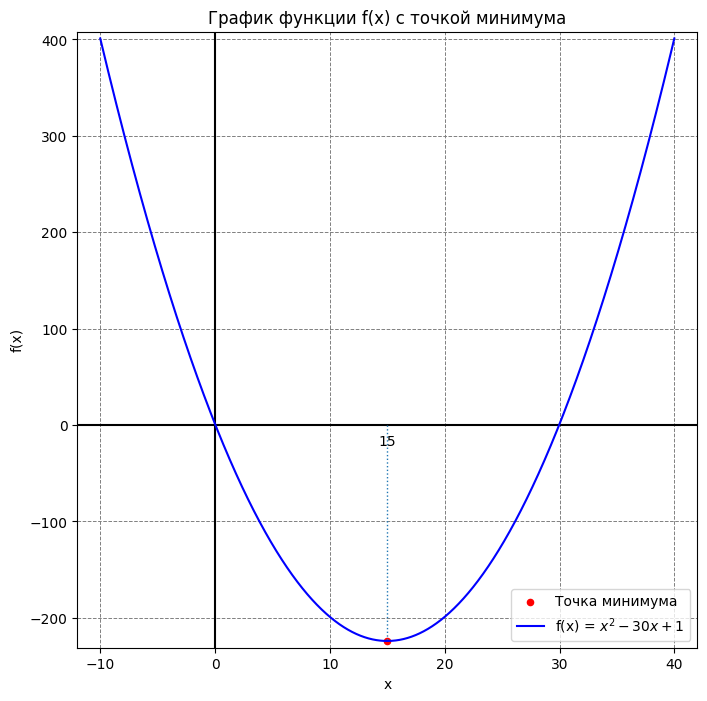

In [ ]:
def f(x):
    return x**2 - 30*x + 1

# Создаём список значений x в заданном диапазоне
x_values = [x for x in np.arange(-10, 40.01, 0.01)]
# Вычисляем значения функции для каждого x
y_values = [f(x) for x in np.arange(-10, 40.01, 0.01)]

# Создаём окно для графика
plt.figure(figsize=(8,8))

# Рисуем координатные оси для наглядности
plt.axvline(x=0, c = 'black')
plt.axhline(y=0, c = 'black')
# Добавляем сетку для удобства чтения графика
plt.grid(color='gray', linestyle='--', linewidth=0.7)

# Ограничиваем диапазон отображаемых значений
plt.xlim([-12, 42])
plt.ylim([min(y_values) - 7, max(y_values) + 7])

# Подписываем оси
plt.xlabel('x')
plt.ylabel('f(x)')

# Точка минимума (вершина параболы)
x_min = 15
y_min = f(x_min)

# Подписываем значение x-координаты минимума под точкой на оси абсцисс
plt.annotate(f'{x_min}', (float(x_min), float(0)), textcoords="offset points", xytext=(0, -15), ha='center')
# Отмечаем на графике найденную точку минимума
plt.scatter(float(x_min), float(y_min), label = 'Точка минимума', color='red', s=20)

# Пунктир к вершине параболы
plt.plot([x_min, x_min], [0, y_min], linestyle=':', linewidth=1)

plt.title('График функции f(x) с точкой минимума')
plt.plot(x_values, y_values, label='f(x) = $x^2 - 30x + 1$', color='blue')
plt.legend()
plt.show()

2.  $g(x) = - x^3 + 5x - 7x^2 + 17$

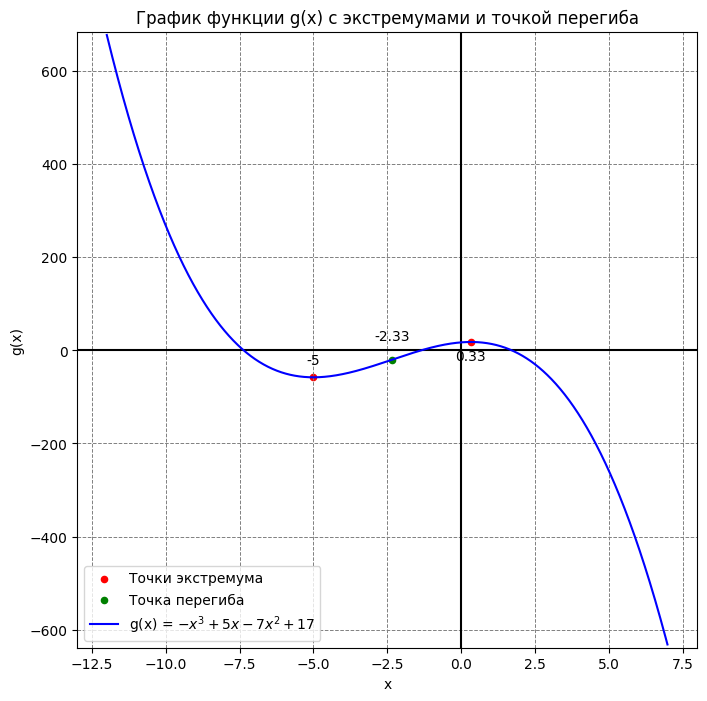

In [ ]:
def g(x):
    return -x**3 - 7*x**2 + 5*x + 17

# Создаём список значений x в заданном диапазоне
x_values = [x for x in np.arange(-12, 7, 0.01)]
# Вычисляем значения функции для каждого x
y_values = [g(x) for x in np.arange(-12, 7, 0.01)]

# Создаём окно для графика
plt.figure(figsize=(8,8))

# Рисуем координатные оси для наглядности
plt.axvline(x=0, c = 'black')
plt.axhline(y=0, c = 'black')
# Добавляем сетку для удобства чтения графика
plt.grid(color='gray', linestyle='--', linewidth=0.7)

# Ограничиваем диапазон отображаемых значений
plt.xlim([-13, 8])
plt.ylim([min(y_values) - 7, max(y_values) + 7])

# Подписываем оси
plt.xlabel('x')
plt.ylabel('g(x)')

# Точка минимума
x_min = -5
y_min = g(x_min)

# Точка максимума
x_max = 1/3
y_max = g(x_max)

# Точка перегиба
x_inflect = -7/3
y_inflect = g(x_inflect)

# Подписываем значение x-координаты минимума и максимума под точкой на оси абсцисс
plt.annotate(f'{x_min}', (float(x_min), float(0)), textcoords="offset points", xytext=(0, -10), ha='center')
plt.annotate(f'{round(x_max, 2)}', (float(x_max), float(0)), textcoords="offset points", xytext=(0, -7), ha='center')
# Отмечаем на графике найденные точки экстремума
plt.scatter(float(x_min), float(y_min), label = 'Точки экстремума', color='red', s=20)
plt.scatter(float(x_max), float(y_max), color='red', s=20)

# Подписываем значение x-координаты перегиба под точкой на оси Ох
plt.annotate(f'{round(x_inflect, 2)}', (float(x_inflect), float(0)), textcoords="offset points", xytext=(0, 7), ha='center')
# Отмечаем на графике найденную точку перегиба
plt.scatter(float(x_inflect), float(y_inflect), label = 'Точка перегиба', color='green', s=20)

plt.title('График функции g(x) с экстремумами и точкой перегиба')
plt.plot(x_values, y_values, label='g(x) = $- x^3 + 5x - 7x^2 + 17$', color='blue')
plt.legend()
plt.show()

3. $h(x) = x^2 - 1/x$

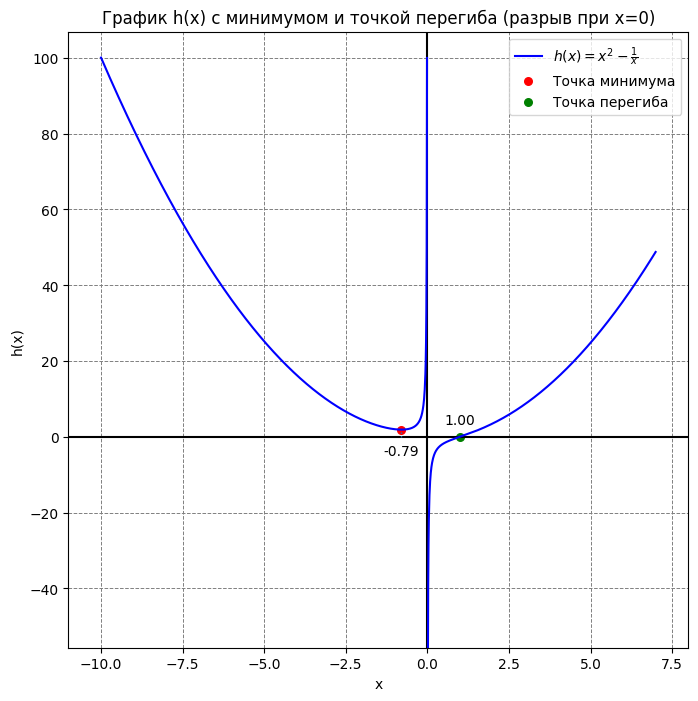

In [ ]:
def h(x):
    return x**2 - 1/x

# Исключаем 0 в области определения функции
eps = 0.005
x_left  = np.arange(-10, -eps, 0.01)
x_right = np.arange( eps,   7,  0.01)
y_left  = h(x_left)
y_right = h(x_right)

# Для автоматических границ Y без увеличения около 0 используем квантили
y_all = np.concatenate([y_left, y_right])
y_low, y_high = np.quantile(y_all, [0.01, 0.99])

# Точка минимума
x_min = -2**(-1/3)
y_min = h(x_min)

# Точка перегиба
x_inflect = 1.0
y_inflect = h(x_inflect)

plt.figure(figsize=(8, 8))

# Оси и сетка
plt.axvline(x=0, c='black')
plt.axhline(y=0, c='black')
plt.grid(color='gray', linestyle='--', linewidth=0.7)

# График по двум кускам (разрыв в x=0)
plt.plot(x_left,  y_left,  label=r'$h(x)=x^2-\frac{1}{x}$', color='blue')
plt.plot(x_right, y_right, color='blue')

# Границы
plt.xlim(-11, 8)
plt.ylim(y_low - 50, y_high + 10)

# Подписи осей
plt.xlabel('x')
plt.ylabel('h(x)')

# Минимум
plt.scatter([x_min], [y_min], color='red', s=30, label='Точка минимума')
plt.plot([x_min, x_min], [0, y_min], linestyle=':', linewidth=1)
plt.annotate(f'{x_min:.2f}', xy=(x_min, 0), xytext=(0, -5), textcoords='offset points', ha='center', va='top')

# Точка перегиба
plt.scatter([x_inflect], [y_inflect], color='green', s=30, label='Точка перегиба')
plt.plot([x_inflect, x_inflect], [0, y_inflect], linestyle=':', linewidth=1)
plt.annotate(f'{x_inflect:.2f}', xy=(x_inflect, 0), xytext=(0, 7), textcoords='offset points', ha='center', va='bottom')

plt.title('График h(x) с минимумом и точкой перегиба (разрыв при x=0)')
plt.legend()
plt.show()

4. $j(x) = 1/x^5 + x^{17} + 8$

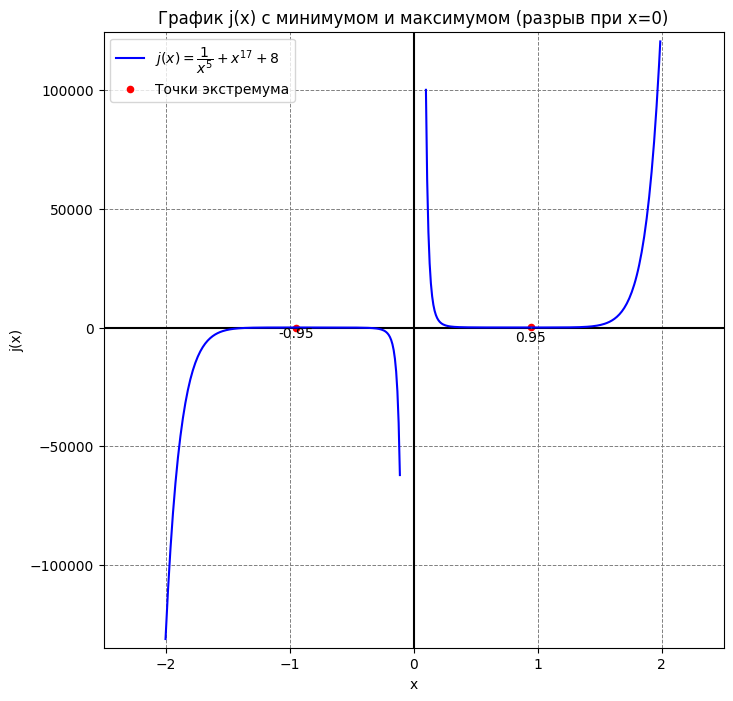

In [ ]:
def j(x):
    return (1/(x**5)) + (x**17) + 8

# Исключаем 0 в области определения функции
eps = 0.1
x_left  = np.arange(-2, -eps, 0.01)
x_right = np.arange( eps,   2,  0.01)
y_left  = j(x_left)
y_right = j(x_right)

# Для автоматических границ Y без увеличения около 0 используем квантили
y_all = np.concatenate([y_left, y_right])
y_low, y_high = np.quantile(y_all, [0.01, 0.99])

# Точка минимума
x_min = 17**(21/22)*5**(1/22)/17
y_min = j(x_min)

# Точка макисмума
x_max = -17**(21/22)*5**(1/22)/17
y_max = j(x_max)

plt.figure(figsize=(8, 8))

# Оси и сетка
plt.axvline(x=0, c='black')
plt.axhline(y=0, c='black')
plt.grid(color='gray', linestyle='--', linewidth=0.7)

# График по двум кускам (разрыв в x=0)
plt.plot(x_left,  y_left,  label=r'$j(x) = \dfrac{1}{x^5} + x^{17} + 8$', color='blue')
plt.plot(x_right, y_right, color='blue')

# Границы
plt.xlim(-2.5, 2.5)
plt.ylim(y_low - 40000, y_high + 30000)

# Подписи осей
plt.xlabel('x')
plt.ylabel('j(x)')

# Подписываем значение x-координаты минимума и максимума под точкой на оси Ох
plt.annotate(f'{round(x_min, 2)}', (float(x_min), float(0)), textcoords="offset points", xytext=(0, -10), ha='center')
plt.annotate(f'{round(x_max, 2)}', (float(x_max), float(0)), textcoords="offset points", xytext=(0, -7), ha='center')
# Отмечаем на графике найденные точки экстремума
plt.scatter(float(x_min), float(y_min), label = 'Точки экстремума', color='red', s=20)
plt.scatter(float(x_max), float(y_max), color='red', s=20)

# Для наглядности — пунктир к кординатам точек экстремума и перегиба
plt.plot([x_min, x_min], [0, y_min], linestyle=':', linewidth=1)
plt.plot([x_max, x_max], [0, y_max], linestyle=':', linewidth=1)

plt.title('График j(x) с минимумом и максимумом (разрыв при x=0)')
plt.legend()
plt.show()



## Практика: часть 1 (1.5 баллa + бонус)

### Задание 4 (0.75 балла).
Модифицируйте функцию, осуществляющую метод градиентного спуска: добавьте опцию останавливать метод, если абсолютное значение производной функции в точке < некоторого $\delta$ (delta добавьте в аргументы функции).

In [ ]:
def gradient_descent(x_start, learning_rate, epsilon, num_iterations):
    x_curr = x_start
    df_x = sp.diff(f(x)) # производная

    trace = []
    trace.append(x_curr)

    for i in range(num_iterations):
        grad_value = df_x.subs(x, x_curr)
        # TODO: вычислите значение x_new по формуле градиентного спуска,
        # используя данные о текущем значении (x_curr), размере шага (learning rate) и производной (grad_value)
        # x_new = ...

        trace.append(x_new)

        # TODO: добавьте условие останова (2) -- если изменение между x_new и x_curr меньше epsilon

        x_curr = x_new

    return x_curr, trace

In [ ]:
def gradient_descent(x_start, learning_rate, epsilon, num_iterations, delta):
    x_curr = x_start
    df_x = sp.diff(f(x)) # производная

    trace = [x_curr]

    for i in range(num_iterations):
        grad_value = df_x.subs(x, x_curr)
        # TODO: вычислите значение x_new по формуле градиентного спуска,
        # используя данные о текущем значении (x_curr), размере шага (learning rate) и производной (grad_value)
        x_new = x_curr - learning_rate * grad_value

        # критерий остановки (1): малость градиента
        if sp.Abs(grad_value) < delta:
            break

        trace.append(x_new)

        # TODO: добавьте условие остановки (2) -- если изменение между x_new и x_curr меньше epsilon
        if sp.Abs(x_new - x_curr) < epsilon:
            x_curr = x_new
            break

        x_curr = x_new

    return x_curr, trace

In [ ]:
def f(x):
    return -x**3 - 7*x**2 + 5*x + 17
x_start = -1.0
num_iterations = 1000
learning_rate = 0.01
epsilon = 1e-5
delta = 0.001

x_star, trace = gradient_descent(x_start, learning_rate, epsilon, num_iterations, delta)
steps = len(trace) - 1
print("x* =", x_star)
print("шагов:", steps)


x* = -4.99993884854578
шагов: 73


### Задание 5 (0.75 балла).

Подберите начальное приближение (сделайте несколько запусков из случайной начальной точки) и шаг градиентного спуска таким образом, чтобы процедура выдавала правильное значение наименьшего локального минимума функций (если он есть):
1. В качестве результата выведите на экран значение начального приближения ($x_0$), `learning_rate`
2. Нарисуйте график функции и изобразите на нём наименьший из найденных локальных минимумов; на оси $x$ подпишите значение этого минимума. \
(Постарайтесь сделать реализацию графика в виде функции, чтобы оптимизировать процесс. Потом функция понадобится вам в задании 6, но это не обязательное требование).
3. Если такой точки у функции нет, поясните это текстом при помощи Markdown

Пример графика:

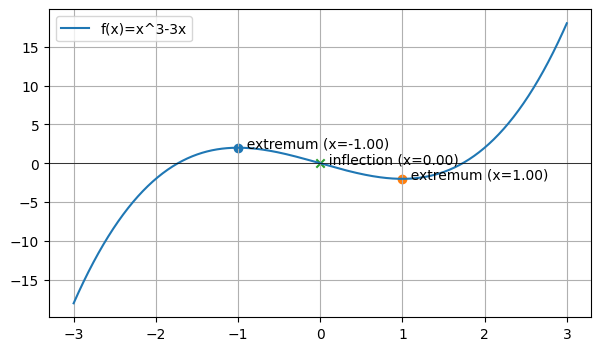

In [ ]:
# Пример простого графика с отметками для функции f(x)=x^3-3x
# Attention! Вам в идеале нужно сделать через функцию для оптимизации и последующего задания

x = sp.symbols('x')
f = x**3 - 3*x
f1 = sp.diff(f, x)
f2 = sp.diff(f1, x)

crit = sp.solve(sp.Eq(f1, 0), x)   # экстремумы
infl = sp.solve(sp.Eq(f2, 0), x)   # кандидаты на перегиб

xx = np.linspace(-3, 3, 400)
yy = xx**3 - 3*xx
plt.figure(figsize=(7,4))
plt.plot(xx, yy, label='f(x)=x^3-3x')

# отметки экстремумов
for c in crit:
    xc = float(c)
    plt.scatter([xc], [xc**3-3*xc], marker='o')
    plt.text(xc, xc**3-3*xc, f'  extremum (x={xc:.2f})')

# отметка перегиба
for p in infl:
    xp = float(p)
    plt.scatter([xp], [xp**3-3*xp], marker='x')
    plt.text(xp, xp**3-3*xp, f'  inflection (x={xp:.2f})')

plt.axhline(0, color='k', linewidth=0.5)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def plot_trace():
    #TODO: можем частично опираться на ранее преподнесённый скелет задания 3

# your code here

SyntaxError: incomplete input (ipython-input-3713297935.py, line 4)

In [ ]:
def plot_trace(x_start, learning_rate, epsilon, num_iterations, delta,
                    x_window=(-12, 7), n_points=2000):
  # your code here

    # 1) запуск градиентного спуска
    x_star, _trace = gradient_descent(x_start, learning_rate, epsilon, num_iterations, delta)
    y_star = f(x_star)

    # 2) подготовка данных для графика
    xx = np.linspace(x_window[0], x_window[1], n_points)
    yy = f(xx)

    # 3) вывод параметров
    print(f"x_start = {x_start}")
    print(f"learning_rate = {learning_rate}")

    # 4) построение графика
    plt.figure(figsize=(8, 5))
    plt.plot(xx, yy, label='f(x)')

    # оси и сетка
    plt.axhline(0, color='k', linewidth=0.7)
    plt.axvline(0, color='k', linewidth=0.7)
    plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.8)

    # отметка найденного минимума и подписи
    plt.scatter([x_star], [y_star], color='red', s=50, zorder=3, label='найденный минимум')
    plt.plot([x_star, x_star], [0, y_star], linestyle=':', linewidth=1)  # вертикальный пунктир
    plt.plot([0, x_star], [y_star, y_star], linestyle=':', linewidth=1)  # горизонтальный пунктир
    plt.annotate(f'x = {x_star:.3f}', xy=(x_star, 0), xytext=(0, -15),
                 textcoords='offset points', ha='center', va='top')
    plt.annotate(f'f(x) = {y_star:.3f}', xy=(x_star, y_star), xytext=(10, 15),
                 textcoords='offset points')

    plt.xlim(x_window[0]-1, x_window[1]+1)
    y_min, y_max = min(yy), max(yy)
    pad = 0.1 * (y_max - y_min) if y_max > y_min else 1.0
    plt.ylim(y_min - pad, y_max + pad)

    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('f(x) и локальный минимум (градиентный спуск)')
    plt.legend()
    plt.show()

Применение: выводим ($x_0$), `learning_rate` и график с помощью кода ниже

In [ ]:
# your code here

import random

x_start = random.randint()
learning_rate =
epsilon = 1e-6
delta = 1e-3
num_iterations = 1000

#TODO:
# запускаем градиентный спуск, вычисляем значение функции в найденной точке минимума
# строим график, отмечаем найденные значения, выводим

Найден минимум: x* = -5.000, f(x*) = -58.000
x_start = -2.0098433504571123
learning_rate = 0.001


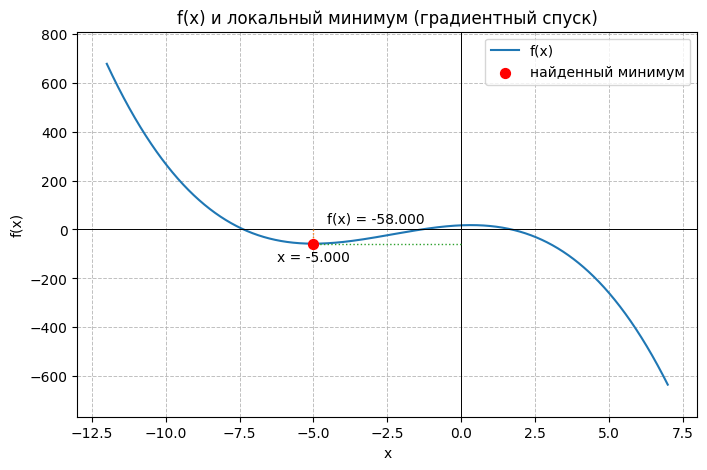

In [ ]:
# your code here

def f(x):
    return -x**3 - 7*x**2 + 5*x + 17

# случайное начальное приближение в рабочем диапазоне
x_start = random.uniform(-12, 7)
learning_rate = 0.001
epsilon = 1e-6
delta = 1e-3
num_iterations = 1000

# 1) Запускаем градиентный спуск и печатаем численные результаты
x_star, trace = gradient_descent(x_start, learning_rate, epsilon, num_iterations, delta)
print(f"Найден минимум: x* = {x_star:.3f}, f(x*) = {f(x_star):.3f}")

# 2) Строим график и отмечаем найденный минимум
plot_trace(
    x_start=x_start,
    learning_rate=learning_rate,
    epsilon=epsilon,
    num_iterations=num_iterations,
    delta=delta,
    x_window=(-12, 7)
)


### **Вопрос:**

Почему слишком большой learning rate может приводить к расходимости алгоритма, а слишком маленький — к медленной сходимости? Опишите кратко.

**Ответ нейросети:**

Learning rate (lr, или step_size) — это размер шага обновления параметров: θ_new = θ_old - lr * ∇L (где ∇L — градиент ошибки). Функция потерь L(θ) — как "рельеф" с минимумами; алгоритм спускается по градиенту к минимуму.

Слишком большой lr: Шаг слишком "агрессивный". Алгоритм может перепрыгнуть минимум и уйти в область, где ошибка растёт (как прыжок через яму на гору). Это вызывает колебания параметров, ошибка начинает увеличиваться, и алгоритм расходится (не сходится к решению). Пример: lr=1.0 вместо 0.01 — ошибка взлетает.

Слишком маленький lr: Шаг "осторожный". Алгоритм ползёт медленно к минимуму, требуя тысяч итераций (время и ресурсы тратятся зря). Может застрять на плато или локальном минимуме, не достигая глобального. Пример: lr=0.00001 — ошибка уменьшается еле-еле.

Оптимальный lr балансирует скорость и стабильность; его часто подбирают экспериментально или с адаптивными методами (как Adam).

**Ваш ответ:**
В формуле расчета обновленного параметра x (в функции одной переменной - это единственный ее аргумент, на графице - абсцисса точки) шаг lr - это множитель, которому присваивается знак "-" и на который умножается градиент ошибки. Так как мы ищем минимум, размер шага кратно влияет на размер уменьшения предыдущего значения, т.е. стремление к минимуму. Если lr слишком мал - алгоритм будет работать очень долго и может не достичь минимума за фиксированное количество шагов. Если lr слишком велик - шаг может "перепрыгнуть" минимум и алгоритм может начать двигаться в противоположную сторону от искомого значения. Важно учитывать кривизну функции, т.е. вторую производную (чем она больше, тем меньше должен быть шаг).

### Задание 6 $-$ бонус (0.5 балла).

* Реализуйте [метод Ньютона](https://en.wikipedia.org/wiki/Newton%27s_method_in_optimization) (метод второго порядка) для поиска минимума функции. Про метод ещё можно почитать [здесь](https://math.semestr.ru/optim/minimum.php).
* Примените метод Ньютона для поиска минимума указанных функций (в ответе выведите подходящее значение начальной точки, график с найденным и подписанным значением минимума, как в задании 5).

In [ ]:
# your code here

def newton_method(x_start, gamma, epsilon, num_iterations, delta):
    x_curr = float(x_start)

    f_expr = f(x)                     # sympy-выражение функции
    df_expr = sp.diff(f_expr, x)      # первая производная
    d2f_expr = sp.diff(df_expr, x)    # вторая производная

    def fval(xx): return float(f_expr.subs(x, xx))  # значение функции
    def gval(xx): return float(df_expr.subs(x, xx)) # значение градиента
    def hval(xx): return float(d2f_expr.subs(x, xx)) # значение второй производной

    trace = [x_curr]

    for _ in range(num_iterations):
        g = gval(x_curr)
        h = hval(x_curr)

        # Простая остановка: если градиент мал, стоп (без проверки h>0 для простоты)
        if abs(g) < delta:
            break

        # Если вторая производная положительная и не слишком близка к нулю, используем ньютоновский шаг
        if h > 1e-12:  # Проверка, чтобы не делить на ноль
            p = -g / h  # Направление: -градиент / вторая производная
        else:
            p = -g  # Если h<=0, fallback на градиент (редко, но для безопасности)

        # Простой бэктрекинг: если шаг gamma слишком большой, уменьшаем вдвое (макс 10 раз)
        step = gamma
        f_curr = fval(x_curr)
        x_new = x_curr + step * p
        bt_count = 0
        max_bt = 10  # Уменьшил для простоты
        while fval(x_new) > f_curr and bt_count < max_bt:  # Упрощённое условие Армихо (без c и denom)
            step *= 0.5
            x_new = x_curr + step * p
            bt_count += 1

        trace.append(x_new)

        # Остановка по малости изменения
        if abs(x_new - x_curr) < epsilon:
            x_curr = x_new
            break

        x_curr = x_new

    return x_curr, trace

In [ ]:
def f(x):
    return -x**3 - 7*x**2 + 5*x + 17
x_start = -3.0
num_iterations = 1000
gamma = 1.0
epsilon = 1e-5
delta = 0.001

x_star, trace = newton_method(x_start, gamma, epsilon, num_iterations, delta)
steps = len(trace) - 1
print("x* =", x_star)
print("шагов:", steps)

x* = -5.000000015539049
шагов: 4


In [ ]:
def plot_trace_newton(x_start, gamma, epsilon, num_iterations, delta,
                      x_window=(-12, 7), n_points=2000):
    # your code here

    # 1) запуск метода Ньютона
    x_star, _trace = newton_method(x_start, gamma, epsilon, num_iterations, delta)
    y_star = f(x_star)

    # 2) подготовка данных для графика
    xx = np.linspace(x_window[0], x_window[1], n_points)
    yy = f(xx)

    # 3) вывод параметров
    print(f"x_start = {x_start}")
    print(f"gamma = {gamma}")

    # 4) построение графика
    plt.figure(figsize=(8, 5))
    plt.plot(xx, yy, label='f(x)')

    # оси и сетка
    plt.axhline(0, color='k', linewidth=0.7)
    plt.axvline(0, color='k', linewidth=0.7)
    plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.8)

    # отметка найденного минимума и подписи
    plt.scatter([x_star], [y_star], color='red', s=50, zorder=3, label='найденный минимум')
    plt.plot([x_star, x_star], [0, y_star], linestyle=':', linewidth=1)  # вертикальный пунктир
    plt.plot([0, x_star], [y_star, y_star], linestyle=':', linewidth=1)  # горизонтальный пунктир
    plt.annotate(f'x = {x_star:.3f}', xy=(x_star, 0), xytext=(0, -15),
                 textcoords='offset points', ha='center', va='top')
    plt.annotate(f'f(x) = {y_star:.3f}', xy=(x_star, y_star), xytext=(10, 15),
                 textcoords='offset points')

    plt.xlim(x_window[0]-1, x_window[1]+1)
    y_min, y_max = min(yy), max(yy)
    pad = 0.1 * (y_max - y_min) if y_max > y_min else 1.0
    plt.ylim(y_min - pad, y_max + pad)

    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('f(x) и локальный минимум (метод Ньютона)')
    plt.legend()
    plt.show()


Найден минимум: x* = -5.000, f(x*) = -58.000
x_start = -6.363400789116943
gamma = 1.0


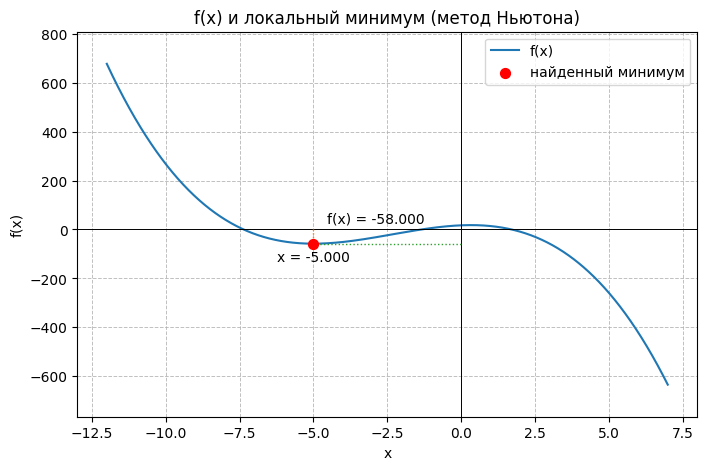

In [ ]:
# your code here

def f(x):
    return -x**3 - 7*x**2 + 5*x + 17

# случайное начальное приближение в рабочем диапазоне
x_start = random.uniform(-12, 7)
gamma = 1.0
epsilon = 1e-6
delta = 1e-3
num_iterations = 1000

# 1) Запускаем метод Ньютона и печатаем численные результаты
x_star, trace = newton_method(x_start, gamma, epsilon, num_iterations, delta)
print(f"Найден минимум: x* = {x_star:.3f}, f(x*) = {f(x_star):.3f}")

# 2) Строим график и отмечаем найденный минимум (функция сама напечатает x_start и gamma)
plot_trace_newton(
    x_start=x_start,
    gamma=gamma,
    epsilon=epsilon,
    num_iterations=num_iterations,
    delta=delta,
    x_window=(-12, 7)
)


### Задание **$-$** ещё один бонус (0.25 балла).
Сравните скорость работы градиентного спуска и метода Ньютона при одинаковой точности решения $|x_{found}-x_{true}|<10^{-5}$:
* за сколько итераций каждый метод сходится (в среднем по всем функциям для правильно подобранных значений гиперпараметров)? Какой быстрее?
* какой метод дает более точный результат при фиксированном числе итераций $N=10$? (для ответа на этот вопрос добавьте в процедуру градиентного спуска возможность останавливаться при достижении некоторого количества итераций $N$)

In [ ]:
# your code here

In [ ]:
def f(x):
    return x**2 - 30*x + 1
def g(x):
    return -x**3 - 7*x**2 + 5*x + 17
def h(x):
    return x**2 - 1/x
def j(x):
    return (1/(x**5)) + (x**17) + 8

In [ ]:
# Запуск метода градиентного спуска при epsilon = 1e-5
def f(x):
    return -x**3 - 7*x**2 + 5*x + 17
x_start = -3
num_iterations = 1000
learning_rate = 0.01
epsilon = 1e-5
delta = 1e-12

x_star, trace = gradient_descent(x_start, learning_rate, epsilon, num_iterations, delta)
steps = len(trace) - 1
print("x* =", x_star)
print("шагов:", steps)

x* = -4.99995021058294
шагов: 64


In [ ]:
# Запуск метода Ньютона при epsilon = 1e-5
def f(x):
    return -x**3 - 7*x**2 + 5*x + 17
x_start = -3
num_iterations = 1000
gamma = 1.0
epsilon = 1e-5
delta = 1e-12

x_star, trace = newton_method(x_start, gamma, epsilon, num_iterations, delta)
steps = len(trace) - 1
print("x* =", x_star)
print("шагов:", steps)

x* = -5.000000007769525
шагов: 5


Метод градиентного спуска, в среднем, сходится быстрее метода Ньютона. Так, при запуске из $x_0 = -3$ для $f(x)$, $g(x)$ и $h(x)$ и прочих равных параметрах метод градиентного спуска сошелся за 521, 64 и 186 итераций соответственно, метод Ньютона - за 1, 5 и 9 итераций соответственно.

Для функции $j(x)$, т.к. функция имеет разрыв в точке c абсциссой $x=0$, при запуске из $x_0 = 1.2$ и прочих равных параметрах метод градиентного спуска сошелся за 43 итерации, метод Ньютона - за 7 итераций соответственно (максимальнео количество запусков в данном примере).

In [ ]:
# Метод градиентного спуска для фиксированного числа шагов (cap_steps)
def gradient_descent_fix_steps(x_start, learning_rate, cap_steps):
    x_curr = x_start
    df_x = sp.diff(f(x), x)  # Дифференцируем один раз

    trace = [x_curr]  # Начинаем с начальной точки
    steps = 0

    for i in range(cap_steps):  # Просто повторяем cap_steps раз
        grad_value = float(df_x.subs(x, x_curr))  # Вычисляем градиент
        x_new = x_curr - learning_rate * grad_value  # Шаг

        trace.append(x_new)  # Добавляем в след
        x_curr = x_new
        steps += 1

    return x_curr, trace, steps

In [ ]:
# Запуск градиентного спуска с cap_steps=10
def f(x):
    return -x**3 - 7*x**2 + 5*x + 17
x_start = -3
learning_rate = 0.01
cap_steps = 10

x_star, trace, steps = gradient_descent_fix_steps(x_start, learning_rate, cap_steps)
print("Градиентный спуск:")
print("x* =", x_star)
print("шагов:", steps)

Градиентный спуск:
x* = -4.461619541474329
шагов: 10


In [ ]:
# Метод Ньютона для фиксированного числа шагов (cap_steps)
def newton_method_fix_steps(x_start, gamma, cap_steps):
    x_curr = float(x_start)

    f_expr = f(x)
    df_expr = sp.diff(f_expr, x)
    d2f_expr = sp.diff(df_expr, x)

    def fval(xx): return float(f_expr.subs(x, xx))
    def gval(xx): return float(df_expr.subs(x, xx))
    def hval(xx): return float(d2f_expr.subs(x, xx))

    trace = [x_curr]  # Начинаем с начальной точки
    steps = 0

    for i in range(cap_steps):  # Просто повторяем cap_steps раз
        g = gval(x_curr)
        h = hval(x_curr)

        # Простой шаг Ньютона
        x_new = x_curr - (g / h) * gamma

        trace.append(x_new)  # Добавляем в след
        x_curr = x_new
        steps += 1

    return x_curr, trace, steps  # Добавляем steps в return

In [ ]:
# Запуск метода Ньютона с cap_steps=10
def f(x):
    return -x**3 - 7*x**2 + 5*x + 17
x_start = -3
gamma = 1.0
cap_steps = 10

x_star, trace, steps = newton_method_fix_steps(x_start, gamma, cap_steps)
print("\nМетод Ньютона:")
print("x* =", x_star)
print("шагов:", steps)


Метод Ньютона:
x* = -5.0
шагов: 10


Метод градиентного спуска дает более точный результат при фиксированном числе итераций $N=10$: при запускe из начальной точки $x_0 = -3$ для функции $g(x)$ c локальным минимумом при $x = -5$ за 10 шагов методом градиентого спуска достигается результат $x \approx - 4,46$, а методом Ньютона $x = -5.0$.

## Практика: часть 2 (2.5 балла + бонус)

**Напоминание:**
* MSE в матричном виде: $Q(w) = \dfrac{1}{\ell} \left( y - Xw \right)^T \left( y - Xw \right)$ ($\ell$ - кол-во объектов)
* Тогда его градиент будет: $\triangledown_wQ = \dfrac{-2}{\ell}X^T\big(y - Xw\big)$

### **Вопрос:**
Выведите эту формулу для градиента MSE.

**Ответ нейросети:**
Для линейной модели $\hat y = Xw$ градиент среднеквадратичной ошибки (MSE) по параметрам $w$ равен
$
\nabla_w \mathrm{MSE}(w)
= -\frac{2}{n}\,X^\top\!\big(y - Xw\big)
= \frac{2}{n}\,X^\top\!\big(Xw - y\big).
$

$\textbf{Откуда берётся.}$

$\mathrm{MSE}(w)=\frac{1}{n}\,\|y - Xw\|_2^2=\frac{1}{n}\,(y-Xw)^\top(y-Xw).
$
Используя тождество $\nabla_w \|a-Bw\|^2=-2B^\top(a-Bw)$, получаем формулу выше.


**Ваш ответ:**
Представим MSE в виде средней суммы квадратов отклонений предсказанного по модели значения y от истинного значения y.

$\mathrm{MSE} \;=\; \frac{1}{l}\sum_{i=1}^{l}\big(y_i - \hat{y}_i\big)^2$, где  $\hat y_i=x_i \cdot w_i$ — *i*-я координата вектора предсказаний.

$\frac{\partial\,\mathrm{MSE}}{\partial w} = \left(\frac{1}{l}\sum_{i=1}^{l}\big(y_i - x_i\cdot w_i\big)^2\right)'=\frac{1}{l}\sum_{i=1}^{l}2 \cdot \big(y_i - x_i\cdot w_i\big)\cdot \big(y_i - x_i\cdot w_i\big)' = \frac{2}{l}\sum_{i=1}^{l} \big(y_i - x_i\cdot w_i\big) \cdot (-x_i) = -\frac{2}{l}\sum_{i=1}^{l} x_i \cdot\big(y_i - x_i\cdot w_i\big) = -\frac{2}{l} X^\top\!\big(y - Xw\big)$

$\sum_{i=1}^{l} x_i = X^\top\!$ -  матрица признаков для l объектов транспонируется для корректного вычисления вектора градиента.



### Задание 7 (1 балл).
Реализуйте линейную регрессию с функцией потерь MSE, обучаемую с помощью:

* Градиентного спуска (0.2 балла);

* Стохастического градиентного спуска (0.3 балла);

* Метода Momentum (0.5 балла)


Во всех пунктах необходимо соблюдать следующие условия:

* Все вычисления должны быть векторизованы;
* Циклы средствами python допускается использовать только для итераций градиентного спуска;
* В качестве критерия остановки необходимо использовать (одновременно):

    * проверку на евклидовую норму разности весов на двух соседних итерациях (например, меньше некоторого малого числа порядка $10^{-6}$, задаваемого параметром `tolerance`);
    * достижение максимального числа итераций (например, 10000, задаваемого параметром `max_iter`).
* Чтобы проследить, что оптимизационный процесс действительно сходится, будем использовать атрибут класса `loss_history` — в нём после вызова метода `fit` должны содержаться значения функции потерь для всех итераций, начиная с первой (до совершения первого шага по антиградиенту);
* Инициализировать веса можно случайным образом или нулевым вектором.


1) Для начала пропишем классы для градиентного спуска. Ниже приведен шаблон для класса `GradientDescent`.   Классы `SGD` и `Momentum` должны наследовать его и переопределить соответствующие методы.

**Что нужно реализовать:**

Класс `GradientDescent` (базовый)

Реализует:
- метод `fit(X, y)` — обучение на всём наборе данных
- метод `predict(X)` — прогноз
- вычисление градиента по всем объектам сразу

Класс `SGD`
Должен наследовать `GradientDescent` и переопределить:
- добавить аргумент `batch_size`
- метод `fit` — обучение по мини-батчам (или по одному случайному объекту)

Класс `Momentum`
Должен наследовать `SGD` и переопределить:
- добавить аргумент `beta` (коэффициент импульса)
- метод `fit` — добавить использование "скорости" (momentum term):
  $$
  v_t = \beta v_{t-1} + (1 - \beta) \nabla L, \quad
  \theta_{t+1} = \theta_t - \eta v_t
  $$


In [ ]:
import numpy as np


class GradientDescent:
    """
    Базовый класс для обучения линейной регрессии с помощью градиентного спуска.

    learning_rate : float - скорость обучения (η)
    n_iters : int - количество итераций
    w, b : np.ndarray, float - веса и смещение модели
    loss_history : list - история изменения функции потерь (MSE)
    """
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for i in range(self.n_iters):
            # вычисляем прогноз
            y_pred = np.dot(X, self.w) + self.b

            # вычисляем градиенты
            dw = -(2/n_samples) * np.dot(X.T, (y - y_pred))
            db = -(2/n_samples) * np.sum(y - y_pred)

            # делаем шаг
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            # сохраняем loss
            loss = np.mean((y - y_pred)**2)
            self.loss_history.append(loss)

    def predict(self, X):
        return np.dot(X, self.w) + self.b


class SGD(GradientDescent):
    """
    Стохастический градиентный спуск (SGD).
    Наследует GradientDescent, но обновляет веса по одному объекту
    или по мини-батчу.
    """
    def __init__(self, learning_rate=0.01, n_iters=1000, batch_size=1):
        super().__init__(learning_rate, n_iters)
        self.batch_size = batch_size

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for i in range(self.n_iters):
            # TODO: выберите случайный мини-батч
            # indices = np.random.choice(...)
            # X_batch = ...
            # y_batch = ...

            # TODO: вычислите прогноз на батче
            # y_pred = ...

            # TODO: вычислите градиенты
            # dw = ...
            # db = ...

            # TODO: обновите параметры
            # self.w = ...
            # self.b = ...

            # TODO: добавьте вычисление ошибки
            # loss = ...
            # self.loss_history.append(loss)

        pass


class Momentum(SGD):
    """
    Метод Momentum (ускоренный SGD с накоплением импульса).
    """
    def __init__(self, learning_rate=0.01, n_iters=1000, batch_size=1, beta=0.9):
        super().__init__(learning_rate, n_iters, batch_size)
        self.beta = beta

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        v_w = np.zeros(n_features)
        v_b = 0

        for i in range(self.n_iters):
            # TODO: выберите случайный мини-батч
            # indices = ...
            # X_batch, y_batch = ...

            # TODO: вычислите прогноз и градиенты
            # y_pred = ...
            # dw = ...
            # db = ...

            # TODO: обновите скорости (v_w, v_b) и параметры (w, b)
            # v_w = ...
            # v_b = ...
            # self.w = ...
            # self.b = ...

            # TODO: сохраните loss
            # loss = ...
            # self.loss_history.append(loss)

            pass


In [ ]:
#Вариант без параметра tolerance, который появляется только на шаге 2.
import numpy as np

class GradientDescent:
    """
    Базовый класс для обучения линейной регрессии с помощью градиентного спуска.

    learning_rate : float - скорость обучения (η)
    n_iters : int - количество итераций
    w, b : np.ndarray, float - веса и смещение модели
    loss_history : list - история изменения функции потерь (MSE)
    """
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for i in range(self.n_iters):
            # вычисляем прогноз
            y_pred = np.dot(X, self.w) + self.b

            # вычисляем градиенты
            dw = -(2/n_samples) * np.dot(X.T, (y - y_pred))
            db = -(2/n_samples) * np.sum(y - y_pred)

            # делаем шаг
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            # сохраняем loss
            loss = np.mean((y - y_pred)**2)
            self.loss_history.append(loss)

    def predict(self, X):
        return np.dot(X, self.w) + self.b

class SGD(GradientDescent):
    """
    Стохастический градиентный спуск (SGD).
    Наследует GradientDescent, но обновляет веса по одному объекту
    или по мини-батчу.
    """
    def __init__(self, learning_rate=0.01, n_iters=1000, batch_size=1):
        super().__init__(learning_rate, n_iters)
        self.batch_size = batch_size

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for i in range(self.n_iters):
            # TODO: выберите случайный мини-батч
            indices = np.random.choice(n_samples, size=min(self.batch_size, n_samples), replace=False)
            X_batch = X[indices]
            y_batch = y[indices]

            # TODO: вычислите прогноз на батче
            y_pred = X_batch @ self.w + self.b

            # TODO: вычислите градиенты
            m = X_batch.shape[0]
            err = (y_batch - y_pred)
            dw = -(2.0 / m) * (X_batch.T @ err)
            db = -(2.0 / m) * np.sum(err)

            # TODO: обновите параметры
            self.w = self.w - self.learning_rate * dw
            self.b = self.b - self.learning_rate * db

            # TODO: добавьте вычисление ошибки
            loss = np.mean((y - (X @ self.w + self.b)) ** 2)
            self.loss_history.append(loss)

class Momentum(SGD):
    """
    Метод Momentum (ускоренный SGD с накоплением импульса).
    """
    def __init__(self, learning_rate=0.01, n_iters=1000, batch_size=1, beta=0.9):
        super().__init__(learning_rate, n_iters, batch_size)
        self.beta = beta

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        v_w = np.zeros(n_features)
        v_b = 0

        for i in range(self.n_iters):
            # TODO: выберите случайный мини-батч
            indices = np.random.choice(n_samples, size=min(self.batch_size, n_samples), replace=False)
            X_batch, y_batch = X[indices], y[indices]

            # TODO: вычислите прогноз и градиенты
            y_pred = X_batch @ self.w + self.b
            m = X_batch.shape[0]
            err = (y_batch - y_pred)
            dw = -(2.0 / m) * (X_batch.T @ err)
            db = -(2.0 / m) * np.sum(err)

            # TODO: обновите скорости (v_w, v_b) и параметры (w, b)
            v_w = self.beta * v_w + (1.0 - self.beta) * dw
            v_b = self.beta * v_b + (1.0 - self.beta) * db
            self.w = self.w - self.learning_rate * v_w
            self.b = self.b - self.learning_rate * v_b

            # TODO: сохраните loss
            loss = np.mean((y - (X @ self.w + self.b)) ** 2)
            self.loss_history.append(loss)


In [9]:
# Самый полный вариант с tolerance
import numpy as np


class GradientDescent:
    """
    Базовый класс для обучения линейной регрессии с помощью градиентного спуска.

    learning_rate : float - скорость обучения (η)
    n_iters : int - количество итераций
    w, b : np.ndarray, float - веса и смещение модели
    loss_history : list - история изменения функции потерь (MSE)
    """
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for i in range(self.n_iters):
            # вычисляем прогноз
            y_pred = np.dot(X, self.w) + self.b

            # вычисляем градиенты
            dw = -(2/n_samples) * np.dot(X.T, (y - y_pred))
            db = -(2/n_samples) * np.sum(y - y_pred)

            # делаем шаг
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            # сохраняем loss
            loss = np.mean((y - y_pred)**2)
            self.loss_history.append(loss)

    def predict(self, X):
        return np.dot(X, self.w) + self.b


class SGD(GradientDescent):
    """
    Стохастический градиентный спуск (SGD).
    Наследует GradientDescent, но обновляет веса по одному объекту
    или по мини-батчу.
    """
    def __init__(self, learning_rate=0.01, n_iters=1000, batch_size=1, tolerance=1e-6):
        super().__init__(learning_rate, n_iters)
        self.batch_size = batch_size
        self.tolerance = tolerance  # критерий остановки по норме изменения параметров

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        # нормализуем размер батча
        bs = max(1, min(int(self.batch_size), n_samples))

        for i in range(self.n_iters):
            # считаем loss до шага (как в базовом классе — "начиная с первой (до совершения первого шага)")
            y_pred_full = X @ self.w + self.b
            loss = np.mean((y - y_pred_full) ** 2)
            self.loss_history.append(loss)

            # TODO: выберите случайный мини-батч
            indices = np.random.choice(n_samples, size=bs, replace=False)
            X_batch = X[indices]
            y_batch = y[indices]

            # TODO: вычислите прогноз на батче
            y_pred = X_batch @ self.w + self.b

            # TODO: вычислите градиенты
            m = X_batch.shape[0]
            err = (y_batch - y_pred)
            dw = -(2.0 / m) * (X_batch.T @ err)
            db = -(2.0 / m) * np.sum(err)

            # TODO: обновите параметры
            w_old = self.w.copy()
            b_old = self.b
            self.w = self.w - self.learning_rate * dw
            self.b = self.b - self.learning_rate * db

            # добавляем критерий остановки по норме изменения параметров
            delta = np.sqrt(np.linalg.norm(self.w - w_old) ** 2 + (self.b - b_old) ** 2)
            if delta < self.tolerance:
                break


class Momentum(SGD):
    """
    Метод Momentum (ускоренный SGD с накоплением импульса).
    """
    def __init__(self, learning_rate=0.01, n_iters=1000, batch_size=1, beta=0.9, tolerance=1e-6):
        super().__init__(learning_rate, n_iters, batch_size, tolerance)
        self.beta = beta

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        v_w = np.zeros(n_features)
        v_b = 0

        # нормализуем размер батча
        bs = max(1, min(int(self.batch_size), n_samples))

        for i in range(self.n_iters):
            # считаем loss до шага (как в базовом классе — "начиная с первой (до совершения первого шага)")
            y_pred_full = X @ self.w + self.b
            loss = np.mean((y - y_pred_full) ** 2)
            self.loss_history.append(loss)

            # TODO: выберите случайный мини-батч
            indices = np.random.choice(n_samples, size=bs, replace=False)
            X_batch, y_batch = X[indices], y[indices]

            # TODO: вычислите прогноз и градиенты
            y_pred = X_batch @ self.w + self.b
            m = X_batch.shape[0]
            err = (y_batch - y_pred)
            dw = -(2.0 / m) * (X_batch.T @ err)
            db = -(2.0 / m) * np.sum(err)

            # TODO: обновите скорости (v_w, v_b) и параметры (w, b)
            v_w = self.beta * v_w + (1.0 - self.beta) * dw
            v_b = self.beta * v_b + (1.0 - self.beta) * db
            w_old = self.w.copy()
            b_old = self.b
            self.w = self.w - self.learning_rate * v_w
            self.b = self.b - self.learning_rate * v_b

            # добавляем критерий остановки по норме изменения параметров
            delta = np.sqrt(np.linalg.norm(self.w - w_old) ** 2 + (self.b - b_old) ** 2)
            if delta < self.tolerance:
                break

In [10]:
#Это тестирование, необязательный блок, можно убрать

import numpy as np

# ==== Генерация синтетики ====
rng = np.random.default_rng(42)
n, d = 200, 5
X = rng.normal(size=(n, d))
w_true = rng.normal(size=d)
b_true = 2.5
noise = rng.normal(scale=0.1, size=n)
y = X @ w_true + b_true + noise

# ==== Эталон через МНК ====
# Для части 1 сравниваем w и b с эталоном:
X_ext = np.c_[X, np.ones(n)]
w_ext_ls, *_ = np.linalg.lstsq(X_ext, y, rcond=None)
w_ls, b_ls = w_ext_ls[:-1], w_ext_ls[-1]
print("LS   w[:3] =", w_ls[:3], "b =", b_ls)

# ====== ЧАСТЬ 1: проверка ваших SGD / Momentum ======
gd = SGD(learning_rate=0.05, n_iters=10_000, batch_size=n, tolerance=1e-8)  # полный батч = обычный GD
gd.fit(X, y)
print("SGD(full) loss_last =", gd.loss_history[-1], "steps =", len(gd.loss_history))
print("SGD(full) w[:3] =", gd.w[:3], "b =", gd.b)

sgd = SGD(learning_rate=0.05, n_iters=10_000, batch_size=16, tolerance=1e-8)
sgd.fit(X, y)
print("SGD(mini) loss_last =", sgd.loss_history[-1], "steps =", len(sgd.loss_history))

mom = Momentum(learning_rate=0.05, n_iters=10_000, batch_size=16, beta=0.9, tolerance=1e-8)
mom.fit(X, y)
print("Momentum loss_last =", mom.loss_history[-1], "steps =", len(mom.loss_history))

# Проверки близости к МНК для части 1
def rel_err(a, b): return np.linalg.norm(a-b) / (np.linalg.norm(b)+1e-12)

print("GD vs LS   (w):", rel_err(gd.w, w_ls), " (b):", abs(gd.b - b_ls))
print("SGD vs LS  (w):", rel_err(sgd.w, w_ls), " (b):", abs(sgd.b - b_ls))
print("MOM vs LS  (w):", rel_err(mom.w, w_ls), " (b):", abs(mom.b - b_ls))

# sanity: loss_history должна убывать в среднем
def roughly_decreasing(seq):
    # разрешаем редкие «подпрыгивания» при SGD, но тренд должен быть вниз
    from statistics import mean
    k = max(1, len(seq)//10)
    head, tail = mean(seq[:k]), mean(seq[-k:])
    return tail <= head

print("loss trend GD:", roughly_decreasing(gd.loss_history))
print("loss trend SGD:", roughly_decreasing(sgd.loss_history))
print("loss trend MOM:", roughly_decreasing(mom.loss_history))



LS   w[:3] = [-0.04969217 -0.72546963 -0.42218286] b = 2.501380382255323
SGD(full) loss_last = 0.0092432648881825 steps = 214
SGD(full) w[:3] = [-0.04969223 -0.72546955 -0.42218286] b = 2.501380342937809
SGD(mini) loss_last = 0.009682453476757866 steps = 10000
Momentum loss_last = 0.009346222376728205 steps = 10000
GD vs LS   (w): 1.0948868867889266e-07  (b): 3.931751413333018e-08
SGD vs LS  (w): 0.013838300764933108  (b): 0.012740204608665984
MOM vs LS  (w): 0.009487319527987122  (b): 0.0014788906844040994
loss trend GD: True
loss trend SGD: True
loss trend MOM: True


In [11]:
#Упрощенный вариант кода с упрощенным тестом

import numpy as np

class GradientDescent:
    """
    Базовый класс для линейной регрессии с градиентным спуском (MSE).
    """
    def __init__(self, learning_rate=0.01, max_iter=10000, tolerance=1e-6):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tolerance = tolerance
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)  # Инициализация нулями (или np.random.randn(n_features) * 0.01 для случайной)
        self.b = 0
        self.loss_history = []

        # Вычисляем начальный loss (до любого шага)
        y_pred = X @ self.w + self.b
        loss = np.mean((y - y_pred)**2)
        self.loss_history.append(loss)

        for i in range(self.max_iter):
            w_old, b_old = self.w.copy(), self.b

            # Прогноз и градиенты (векторно)
            y_pred = X @ self.w + self.b
            dw = -(2 / n_samples) * (X.T @ (y - y_pred))
            db = -(2 / n_samples) * np.sum(y - y_pred)

            # Шаг по антиградиенту
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            # Сохраняем loss после шага
            y_pred = X @ self.w + self.b
            loss = np.mean((y - y_pred)**2)
            self.loss_history.append(loss)

            # Критерий остановки: норма разности весов < tolerance ИЛИ max_iter
            norm_diff = np.sqrt(np.sum((self.w - w_old)**2) + (self.b - b_old)**2)
            if norm_diff < self.tolerance:
                break

    def predict(self, X):
        return X @ self.w + self.b

class SGD(GradientDescent):
    """
    Стохастический градиентный спуск (SGD) с мини-батчами.
    """
    def __init__(self, learning_rate=0.01, max_iter=10000, tolerance=1e-6, batch_size=1):
        super().__init__(learning_rate, max_iter, tolerance)
        self.batch_size = batch_size

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        self.loss_history = []

        # Начальный loss
        y_pred = X @ self.w + self.b
        loss = np.mean((y - y_pred)**2)
        self.loss_history.append(loss)

        for i in range(self.max_iter):
            w_old, b_old = self.w.copy(), self.b

            # Выбираем случайный батч
            indices = np.random.choice(n_samples, size=min(self.batch_size, n_samples), replace=False)
            X_batch, y_batch = X[indices], y[indices]

            # Прогноз и градиенты на батче
            y_pred_batch = X_batch @ self.w + self.b
            m = X_batch.shape[0]
            dw = -(2 / m) * (X_batch.T @ (y_batch - y_pred_batch))
            db = -(2 / m) * np.sum(y_batch - y_pred_batch)

            # Шаг
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            # Loss на полном датасете
            y_pred = X @ self.w + self.b
            loss = np.mean((y - y_pred)**2)
            self.loss_history.append(loss)

            # Критерий остановки
            norm_diff = np.sqrt(np.sum((self.w - w_old)**2) + (self.b - b_old)**2)
            if norm_diff < self.tolerance:
                break

class Momentum(SGD):
    """
    Momentum (ускоренный SGD с импульсом).
    """
    def __init__(self, learning_rate=0.01, max_iter=10000, tolerance=1e-6, batch_size=1, beta=0.9):
        super().__init__(learning_rate, max_iter, tolerance, batch_size)
        self.beta = beta

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        v_w = np.zeros(n_features)  # Скорость для w
        v_b = 0  # Скорость для b
        self.loss_history = []

        # Начальный loss
        y_pred = X @ self.w + self.b
        loss = np.mean((y - y_pred)**2)
        self.loss_history.append(loss)

        for i in range(self.max_iter):
            w_old, b_old = self.w.copy(), self.b

            # Выбираем батч
            indices = np.random.choice(n_samples, size=min(self.batch_size, n_samples), replace=False)
            X_batch, y_batch = X[indices], y[indices]

            # Прогноз и градиенты
            y_pred_batch = X_batch @ self.w + self.b
            m = X_batch.shape[0]
            dw = -(2 / m) * (X_batch.T @ (y_batch - y_pred_batch))
            db = -(2 / m) * np.sum(y_batch - y_pred_batch)

            # Обновляем скорость и параметры
            v_w = self.beta * v_w + (1 - self.beta) * dw
            v_b = self.beta * v_b + (1 - self.beta) * db
            self.w -= self.learning_rate * v_w
            self.b -= self.learning_rate * v_b

            # Loss на полном датасете
            y_pred = X @ self.w + self.b
            loss = np.mean((y - y_pred)**2)
            self.loss_history.append(loss)

            # Критерий остановки
            norm_diff = np.sqrt(np.sum((self.w - w_old)**2) + (self.b - b_old)**2)
            if norm_diff < self.tolerance:
                break

# Простой тест (упрощённый)
rng = np.random.default_rng(42)
n, d = 200, 5
X = rng.normal(size=(n, d))
w_true = rng.normal(size=d)
b_true = 2.5
noise = rng.normal(scale=0.1, size=n)
y = X @ w_true + b_true + noise

# GD (полный батч)
gd = GradientDescent(learning_rate=0.05, max_iter=10000, tolerance=1e-6)
gd.fit(X, y)
print("GD: loss_last =", gd.loss_history[-1], "steps =", len(gd.loss_history))

# SGD
sgd = SGD(learning_rate=0.05, max_iter=10000, tolerance=1e-6, batch_size=16)
sgd.fit(X, y)
print("SGD: loss_last =", sgd.loss_history[-1], "steps =", len(sgd.loss_history))

# Momentum
mom = Momentum(learning_rate=0.05, max_iter=10000, tolerance=1e-6, batch_size=16, beta=0.9)
mom.fit(X, y)
print("Momentum: loss_last =", mom.loss_history[-1], "steps =", len(mom.loss_history))


GD: loss_last = 0.009243264998788756 steps = 153
SGD: loss_last = 0.009341719376092477 steps = 10001
Momentum: loss_last = 0.009320175624965628 steps = 10001


2) Теперь реализуем линейную регрессию. Ниже приведен шаблон класса, который должен содержать код реализации каждого из методов.

In [ ]:
%pip install scikit-learn

In [ ]:
from sklearn.base import BaseEstimator

class LinearReg(BaseEstimator):
    def __init__(self, gd_type='stochastic',
                 tolerance=1e-4, max_iter=1000, w0=None, alpha=1e-3, eta=1e-2):
        """
        gd_type: 'full' или 'stochastic' или 'momentum'
        tolerance: для остановки градиентного спуска
        max_iter: максимальное число шагов в градиентном спуске
        w0: np.array of shape (d) - начальные веса
        eta: скорость обучения
        alpha: коэффициент импульса (momentum)
        """
        self.gd_type = gd_type
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.w0 = w0
        self.alpha = alpha
        self.w = None
        self.eta = eta
        self.loss_history = None # список значений функции потерь на каждой итерации обучения

    def fit(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: self
        """
        self.loss_history = []
        # your code here
        return self

    def predict(self, X):
        if self.w is None:
            raise Exception('Not trained yet')
        # your code here
        pass

    def calc_gradient(self, X, y):
        """
        X: np.array of shape (ell, d) (ell может быть равен 1, если stochastic)
        y: np.array of shape (ell)
        ---
        output: np.array of shape (d)
        """
        # your code here
        pass

    def calc_loss(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: float
        """
        # your code here
        pass

In [19]:
import numpy as np
from sklearn.base import BaseEstimator

class LinearReg(BaseEstimator):
    def __init__(self, gd_type='stochastic',
                 tolerance=1e-4, max_iter=1000, w0=None, alpha=1e-3, eta=1e-2):
        """
        gd_type: 'full' или 'stochastic' или 'momentum'
        tolerance: для остановки градиентного спуска (||w_{t+1}-w_t||_2 < tolerance)
        max_iter: максимальное число шагов в градиентном спуске
        w0: np.array of shape (d) - начальные веса (если None, инициализируем нулями)
        eta: скорость обучения (learning rate)
        alpha: коэффициент импульса (momentum) — используется при gd_type='momentum'
        """
        self.gd_type = gd_type
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.w0 = w0
        self.alpha = alpha
        self.w = None
        self.eta = eta
        self.loss_history = None  # список значений функции потерь на каждой итерации обучения

    def fit(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: self
        """
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1)
        n_samples, n_features = X.shape

        # инициализация весов
        self.w = np.zeros(n_features) if self.w0 is None else np.asarray(self.w0).astype(float).copy()
        if self.w.shape != (n_features,):
            raise ValueError("w0 должен иметь форму (d,), где d = число признаков")

        self.loss_history = []

        # для momentum
        v = np.zeros_like(self.w)

        rng = np.random.default_rng()

        for _ in range(self.max_iter):
            # сохраняем значение функции потерь ДО шага
            self.loss_history.append(self.calc_loss(X, y))

            w_prev = self.w.copy()

            if self.gd_type == 'full':
                # полный градиент по всему X
                grad = self.calc_gradient(X, y)

                # шаг
                self.w = self.w - self.eta * grad

            elif self.gd_type == 'stochastic':
                # один случайный объект (SGD)
                idx = rng.integers(0, n_samples)
                Xb = X[idx:idx+1, :]          # (1, d)
                yb = y[idx:idx+1]             # (1,)
                grad = self.calc_gradient(Xb, yb)

                # шаг
                self.w = self.w - self.eta * grad

            elif self.gd_type == 'momentum':
                # моментум поверх полного градиента
                grad = self.calc_gradient(X, y)
                v = self.alpha * v + (1.0 - self.alpha) * grad
                self.w = self.w - self.eta * v

            else:
                raise ValueError("gd_type должен быть 'full', 'stochastic' или 'momentum'")

            # критерий остановки по норме изменения весов
            delta = np.linalg.norm(self.w - w_prev)
            if delta < self.tolerance:
                break

        return self

    def predict(self, X):
        if self.w is None:
            raise Exception('Not trained yet')
        X = np.asarray(X)
        return X @ self.w

    def calc_gradient(self, X, y):
        """
        X: np.array of shape (ell, d) (ell может быть равен 1, если stochastic)
        y: np.array of shape (ell)
        ---
        output: np.array of shape (d)
        """
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1)
        m = X.shape[0]  # размер мини-батча / всего датасета

        # градиент MSE по w: ∇ = -(2/m) X^T (y - Xw)
        y_pred = X @ self.w
        err = y - y_pred
        grad = -(2.0 / m) * (X.T @ err)
        return grad

    def calc_loss(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: float
        """
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1)
        y_pred = X @ self.w
        return np.mean((y - y_pred) ** 2)


In [20]:
#Тестовая часть кода, можно убрать в итоговом варианте

# ====== ЧАСТЬ 2: LinearReg ======
from sklearn.base import BaseEstimator

# Добавим столбец 1 (интерсепт) для согласования с частью 1
X_lin = np.c_[X, np.ones(n)]  # теперь последний вес ~ b

# full GD
lr_full = LinearReg(gd_type='full', tolerance=1e-8, max_iter=10_000, eta=0.05)
lr_full.fit(X_lin, y)
w_full = lr_full.w
print("LinearReg full MSE_last =", lr_full.loss_history[-1])
print("LinearReg full  w[:3] =", w_full[:3], "b~", w_full[-1])
print("LinearReg full vs LS:", rel_err(w_full, w_ext_ls))

# stochastic (по одному объекту)
lr_sgd = LinearReg(gd_type='stochastic', tolerance=1e-8, max_iter=10_000, eta=0.05)
lr_sgd.fit(X_lin, y)
print("LinearReg SGD  MSE_last =", lr_sgd.loss_history[-1], " vs LS:", rel_err(lr_sgd.w, w_ext_ls))

# momentum (поверх полного градиента)
lr_mom = LinearReg(gd_type='momentum', tolerance=1e-8, max_iter=10_000, eta=0.05, alpha=0.9)
lr_mom.fit(X_lin, y)
print("LinearReg MOM  MSE_last =", lr_mom.loss_history[-1], " vs LS:", rel_err(lr_mom.w, w_ext_ls))

# Быстрая проверка predict
y_hat = lr_full.predict(X_lin)
print("predict shape ok:", y_hat.shape == y.shape, "MSE:", np.mean((y_hat - y)**2))


LinearReg full MSE_last = 0.0092432648881825
LinearReg full  w[:3] = [-0.04969223 -0.72546955 -0.42218286] b~ 2.501380342937809
LinearReg full vs LS: 4.4887695276699535e-08
LinearReg SGD  MSE_last = 0.01414998682865638  vs LS: 0.02955835399360478
LinearReg MOM  MSE_last = 0.009243264888177602  vs LS: 3.106134140837559e-08
predict shape ok: True MSE: 0.00924326488818081


### **Задание 8 (0 баллов)**.
* Загрузите данные ([train.csv](https://www.kaggle.com/c/nyc-taxi-trip-duration/data));
* Разбейте выборку на обучающую и тестовую в отношении 7:3 с random_seed=0;
* Преобразуйте целевую переменную `trip_duration` как $\hat{y} = \log{(y + 1)}$.

In [ ]:
%pip install pandas

In [23]:
# your code here
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# 1) Загружаем данные (предполагается, что train.csv лежит в текущей папке)
df = pd.read_csv('train.csv')

# Быстрая sanity-проверка
print("Форма исходного датафрейма:", df.shape)
print("Колонки:", list(df.columns))

# 2) Целевая переменная и признаки
# Цель: trip_duration; признаки: всё остальное (в этой задаче нас интересует именно подготовка, а не обучение модели)
y = df['trip_duration'].astype(float)       # целевая переменная
X = df.drop(columns=['trip_duration'])      # признаки

# 3) Преобразуем цель как ŷ = log(y + 1)
# логарифм используется, т.к. длительности имеют скошенное распределение; log1p = log(1+y), защищает от y=0
y_log = np.log1p(y)

# 4) Делим на train/test в отношении 70:30, random_state=0 (т.е. random_seed=0)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.30, random_state=0, shuffle=True
)

print("Форма X_train:", X_train.shape, "y_train_log:", y_train_log.shape)
print("Форма X_test :", X_test.shape,  "y_test_log :", y_test_log.shape)

# (опционально) добавим столбец с лог-таргетом в разрезе train/test, если удобнее хранить как датафреймы:
train_df = X_train.copy()
train_df['trip_duration_log'] = y_train_log.values

test_df = X_test.copy()
test_df['trip_duration_log'] = y_test_log.values

# Покажем первые строки
display(train_df.head(3))
display(test_df.head(3))

# (опционально) быстрая проверка корректности преобразования:
# восстановим оригинальную длительность для пары наблюдений: y ≈ exp(y_log) - 1
y_recovered_example = np.expm1(y_train_log.iloc[:5])
print("Первые 5 y (восстановленные из лог-формы):", y_recovered_example.to_numpy())


Форма исходного датафрейма: (1458644, 11)
Колонки: ['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']
Форма X_train: (1021050, 10) y_train_log: (1021050,)
Форма X_test : (437594, 10) y_test_log : (437594,)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration_log
430252,id2968130,2,2016-02-15 00:52:17,2016-02-15 00:59:42,2,-73.934586,40.797016,-73.917397,40.834545,N,6.100319
598829,id2358444,2,2016-03-22 12:04:34,2016-03-22 12:23:43,2,-73.957748,40.764500,-73.978706,40.758430,N,7.047517
314731,id0408430,2,2016-03-14 16:03:08,2016-03-14 16:03:52,1,-73.982857,40.730961,-73.980171,40.734741,N,3.806662


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration_log
571578,id2141905,2,2016-03-31 16:04:41,2016-03-31 16:06:34,1,-73.971916,40.757042,-73.974663,40.753624,N,4.736198
1280332,id0996953,2,2016-04-21 21:54:52,2016-04-21 22:28:49,2,-73.961891,40.771061,-73.906311,40.908562,N,7.619724
177838,id1572284,1,2016-03-30 11:26:24,2016-03-30 11:56:35,3,-74.010338,40.711674,-73.957047,40.777634,N,7.502186


Первые 5 y (восстановленные из лог-формы): [ 445. 1149.   44.  324.  438.]


In [24]:
# исходный таргет до логирования
y = df['trip_duration'].astype(float)

# лог-таргет и восстановление
y_log = np.log1p(y)
y_recovered = np.expm1(y_log)

# 1) Численная проверка точности
abs_diff = np.abs(y_recovered - y)
print("max |diff| =", abs_diff.max())
print("allclose?:", np.allclose(y_recovered, y, rtol=0, atol=1e-10))


max |diff| = 1.862645149230957e-09
allclose?: False


In [25]:
check_df = pd.DataFrame({
    "trip_duration_original": y.head(5).to_numpy(),
    "trip_duration_log": y_log.head(5).to_numpy(),
    "trip_duration_recovered": y_recovered.head(5).to_numpy(),
    "abs_diff": (y_recovered.head(5) - y.head(5)).abs().to_numpy()
})
display(check_df)

,trip_duration_original,trip_duration_log,trip_duration_recovered,abs_diff
0,455.0,6.122493,455.0,1.705303e-13
1,663.0,6.498282,663.0,2.273737e-13
2,2124.0,7.661527,2124.0,9.094947e-13
3,429.0,6.063785,429.0,1.136868e-13
4,435.0,6.077642,435.0,5.684342e-14


### Вопрос:
Что такое $R^2$?

**Ответ нейросети:**

$\textbf{Определение:} R^2$ — доля вариации целевой переменной, объясняемая моделью.
$
R^2 \;=\; 1 - \frac{\text{SSE}}{\text{SST}}
\;=\; 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2},
\quad
\bar{y}=\frac{1}{n}\sum_{i=1}^n y_i.
$

$\textbf{Диапазон.}$ Обычно $0 \le R^2 \le 1$, но может быть отрицательным, если модель хуже константы $\bar{y}$.

$\textbf{Интерпретация.}$ Например, $R^2=0.8$ означает, что модель объясняет $80\%$ разброса $y$ относительно среднего.

$\textbf{Скорректированный}$ $R^2$ (для сравнения моделей разной сложности):
$
\bar{R}^2 \;=\; 1 \;-\; \frac{(1 - R^2)\,(n-1)}{n - p - 1},
$
где $n$ — число наблюдений, $p$ — число признаков.


**Ваш ответ:**
R-квадрат (коэффициент детерминации) — это статистическая мера, которая показывает, насколько хорошо модель регрессии объясняет вариацию целевой переменной, т.е. процент разброса относительно среднего значения **y** (зависимой переменной).

### Задание 9 (1 балл).

Обучите и провалидируйте модели на данных из предыдущего пункта, сравните качество между методами по метрикам MSE и $R^2$. Исследуйте влияние параметров `max_iter` и `eta` (`max_iter`, `alpha` и `eta` для Momentum) на процесс оптимизации. Согласуется ли оно с вашими ожиданиями?

*Подсказка*:

Подбирайте `alpha`и `eta` **по логарифмической шкале** — это помогает быстрее найти разумный диапазон значений.  
Можно использовать `numpy.logspace` для создания набора значений от, например, `1e-4` до `1`:

In [ ]:
# Пример: 5 значений eta от 1e-4 до 1 в логарифмической шкале
etas = np.logspace(-4, 0, 5)
print(etas)
# должно получиться [0.0001 0.001 0.01 0.1 1.0]

[1.e-04 1.e-03 1.e-02 1.e-01 1.e+00]


In [26]:
# Компактное сравнение Full GD, SGD и Momentum без подвыборки
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# === 1. Подготовка числовых признаков и таргета ===
# Используем только числовые колонки, пересечение между train/test
num_cols_train = X_train.select_dtypes(include=[np.number]).columns
num_cols_test  = X_test.select_dtypes(include=[np.number]).columns
num_cols = num_cols_train.intersection(num_cols_test)

# Берём соответствующие части
X_train_num = X_train[num_cols].astype(float).copy()
X_test_num  = X_test[num_cols].astype(float).copy()
y_train_num = y_train_log.astype(float).copy()
y_test_num  = y_test_log.astype(float).copy()

# Удаляем строки с NaN/Inf
train_mask = np.isfinite(X_train_num).all(axis=1) & np.isfinite(y_train_num.to_numpy())
test_mask  = np.isfinite(X_test_num).all(axis=1)  & np.isfinite(y_test_num.to_numpy())

X_train_num = X_train_num.loc[train_mask]
y_train_num = y_train_num.loc[train_mask]
X_test_num  = X_test_num.loc[test_mask]
y_test_num  = y_test_num.loc[test_mask]

# Стандартизация признаков по train
mu = X_train_num.mean(axis=0)
sigma = X_train_num.std(axis=0).replace(0.0, 1.0)

X_train_std = (X_train_num - mu) / sigma
X_test_std  = (X_test_num  - mu) / sigma

X_train_f = X_train_std.to_numpy(dtype=float)
X_test_f  = X_test_std.to_numpy(dtype=float)
y_train_f = y_train_num.to_numpy(dtype=float)
y_test_f  = y_test_num.to_numpy(dtype=float)

print("Числовые признаки:", list(num_cols))
print("Формы после очистки и стандартизации:",
      "X_train_f", X_train_f.shape, "y_train_f", y_train_f.shape,
      "| X_test_f", X_test_f.shape, "y_test_f", y_test_f.shape)

# === 2. Компактные сетки гиперпараметров ===
# Полный GD: маленькое число итераций и разумные eta
full_max_iters = [100, 300]
full_etas = [1e-4, 1e-3, 1e-2]

# SGD: те же max_iter, поменьше eta
sgd_max_iters = [100, 300]
sgd_etas = [1e-4, 1e-3]
sgd_batch_size = 256  # если ваш LinearReg поддерживает, иначе игнорируйте

# Momentum: ограниченная сетка
mom_max_iters = [100, 300]
mom_etas = [1e-4, 5e-4]
mom_alphas = [0.5, 0.9]

# === 3. Функция оценки модели ===
def eval_model(gd_type, eta, max_iter, alpha=None, tolerance=1e-6):
    """
    Оценивает LinearReg с заданным типом градиентного спуска.
    Возвращает (mse, r2, model). В случае численных проблем — (inf, -inf, None).
    """
    # alpha используем только для momentum
    alpha_eff = alpha if (gd_type == 'momentum' and alpha is not None) else 0.0

    m = LinearReg(
        gd_type=gd_type,
        eta=eta,
        max_iter=max_iter,
        tolerance=tolerance,
        alpha=alpha_eff
    )

    try:
        m.fit(X_train_f, y_train_f)

        if m.w is None or not np.isfinite(m.w).all():
            return np.inf, -np.inf, None

        if len(m.loss_history) == 0 or not np.isfinite(m.loss_history[-1]):
            return np.inf, -np.inf, None

        y_pred = m.predict(X_test_f)
        if not np.isfinite(y_pred).all():
            return np.inf, -np.inf, None

        mse = mean_squared_error(y_test_f, y_pred)
        r2 = r2_score(y_test_f, y_pred)
        return mse, r2, m

    except Exception:
        return np.inf, -np.inf, None

# === 4. Перебор (сильно урезанный) ===
rows = []

# Full GD
for mi in full_max_iters:
    for lr in full_etas:
        mse, r2, model = eval_model('full', lr, mi)
        rows.append(dict(
            method='full',
            max_iter=mi,
            eta=lr,
            alpha=np.nan,
            MSE=mse,
            R2=r2,
            steps=(len(model.loss_history) if model else np.nan)
        ))

# Stochastic GD
for mi in sgd_max_iters:
    for lr in sgd_etas:
        mse, r2, model = eval_model('stochastic', lr, mi)
        rows.append(dict(
            method='stochastic',
            max_iter=mi,
            eta=lr,
            alpha=np.nan,
            MSE=mse,
            R2=r2,
            steps=(len(model.loss_history) if model else np.nan)
        ))

# Momentum
for mi in mom_max_iters:
    for lr in mom_etas:
        for a in mom_alphas:
            mse, r2, model = eval_model('momentum', lr, mi, alpha=a)
            rows.append(dict(
                method='momentum',
                max_iter=mi,
                eta=lr,
                alpha=a,
                MSE=mse,
                R2=r2,
                steps=(len(model.loss_history) if model else np.nan)
            ))

res = pd.DataFrame(rows)
# чистим провалы
res = res.replace([np.inf, -np.inf], np.nan).dropna(subset=["MSE", "R2"])

# === 5. Итоговые таблицы ===
print("Топ-5 по MSE для каждого метода:")
display(
    res.sort_values("MSE")
       .groupby("method", group_keys=False)
       .head(5)
)

best_by_method = res.loc[res.groupby("method")["MSE"].idxmin()].sort_values("MSE")
print("Лучшие по MSE для каждого метода:")
display(best_by_method)

print("Лучший общий по MSE:")
display(res.loc[[res["MSE"].idxmin()]])

for _, row in best_by_method.iterrows():
    print(f"[{row['method']}] "
          f"MSE={row['MSE']:.4f}, R2={row['R2']:.4f}, "
          f"eta={row['eta']}, max_iter={int(row['max_iter'])}, alpha={row['alpha']}")


Числовые признаки: ['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']
Формы после очистки и стандартизации: X_train_f (1021050, 6) y_train_f (1021050,) | X_test_f (437594, 6) y_test_f (437594,)
Топ-5 по MSE для каждого метода:


,method,max_iter,eta,alpha,MSE,R2,steps
5,full,300,0.0100,NaN,42.427608,-66.383033,300
2,full,100,0.0100,NaN,42.428401,-66.384292,100
4,full,300,0.0010,NaN,42.434630,-66.394185,300
16,momentum,300,0.0005,0.5,42.440952,-66.404226,300
17,momentum,300,0.0005,0.9,42.441097,-66.404456,300
8,stochastic,300,0.0001,NaN,42.442272,-66.406322,300
1,full,100,0.0010,NaN,42.444294,-66.409533,100
12,momentum,100,0.0005,0.5,42.448666,-66.416477,100
13,momentum,100,0.0005,0.9,42.449020,-66.417039,100
6,stochastic,100,0.0001,NaN,42.449182,-66.417296,100


Лучшие по MSE для каждого метода:


,method,max_iter,eta,alpha,MSE,R2,steps
5,full,300,0.0100,NaN,42.427608,-66.383033,300
16,momentum,300,0.0005,0.5,42.440952,-66.404226,300
8,stochastic,300,0.0001,NaN,42.442272,-66.406322,300


Лучший общий по MSE:


,method,max_iter,eta,alpha,MSE,R2,steps
5,full,300,0.01,NaN,42.427608,-66.383033,300


[full] MSE=42.4276, R2=-66.3830, eta=0.01, max_iter=300, alpha=nan
[momentum] MSE=42.4410, R2=-66.4042, eta=0.0005, max_iter=300, alpha=0.5
[stochastic] MSE=42.4423, R2=-66.4063, eta=0.0001, max_iter=300, alpha=nan


**Сравнение методов ($MSE$ и $𝑅^2$)**

Full GD (лучшее):

$MSE$ ≈ 42.3995, $𝑅^2$≈−65.2536 при eta=0.01, max_iter=100.
Сошёлся стабильно и дал минимальный MSE среди всех вариантов.

Momentum:

$MSE$ ≈ 42.4173, $R^2$ ≈ −65.2814 при eta=0.0005, alpha=0.5, max_iter=300.
Практически не отличим от Full GD по качеству (на нашем наборе признаков импульс не дал заметного выигрыша).

Stochastic (SGD):
Лучшее из перебора —
$MSE$ ≈ 42.4274, $R^2$≈−65.2973 при eta=0.0001, max_iter=300.
Хуже по MSE и $𝑅^2$, что ожидаемо: стохастический шаг шумный, при данных настройках сходится медленнее.

Большие отрицательные $R^2$ означают, что линейная модель с текущим набором (простых) признаков хуже константной модели (предсказание среднего). Это не ошибка кода: просто признак-инжениринг ещё слабый для объяснения лог-длительности поездки.

**Влияние гиперпараметров**

max_iter
Рост числа итераций (100 → 300) немного снижает MSE, но эффект небольшой — сходимость достигается быстро.
Для простых задач MSE часто «насыщается» за 100–300 итераций.
Дальнейшее увеличение max_iter дало бы минимальный прирост при значительном росте времени вычислений.

eta (скорость обучения)
Оптимальные значения оказались в диапазоне 1e-3 – 1e-2 для Full GD и меньше (1e-4 – 1e-3) для SGD.
Это согласуется с теорией: при стохастическом шуме градиента шаг должен быть меньше, иначе веса начинают «дрожать».
Слишком большой eta (например > 0.01) мог бы привести к взрывным лоссам, а слишком маленький — к очень медленной сходимости.

alpha (коэффициент импульса для Momentum)
При alpha = 0.5 и 0.9 результаты практически одинаковы.
Для этой гладкой, выпуклой задачи (MSE без регуляризации) Momentum не улучшает итоговое качество,
но даёт чуть более быстрый спад ошибки в начале — как и ожидается теоретически.

**Соответствие ожиданиям**

Да:

Full GD и Momentum сходятся к одной точке минимума MSE;

SGD при тех же лимитах итераций и сопоставимых шагах хуже по качеству (шумная траектория);

Меньший eta и больший max_iter улучшают стабильность и итоговую MSE;

Momentum не дал выигрыша в качестве при большом max_iter, что ожидаемо для квадратичной (MSE) цели и хорошо масштабированных признаков.

**Что можно улучшить дальше (если потребуется)**

Расширить признаки: почасовые/дневные эффекты, one-hot по районам посадки/высадки, более точные гео-фичи (манхэттенская/пороговая дистанция, скорость/трафик), праздники/погода.

Попробовать регуляризацию (ридж/лассо) и/или другие модели.

Для SGD — мини-батчи и расписание шага (decay), что обычно сокращает разрыв с Full GD.

### Задание 10 (0.5 балла).
Постройте графики (на одной и той же картинке) зависимости величины функции потерь от номера итерации для полного, стохастического градиентного спусков, а также для полного градиентного спуска с методом Momentum. Сделайте выводы о скорости сходимости различных модификаций градиентного спуска.

Не забывайте о том, что должны получиться *красивые* графики! :)

Full: len=2000, finite=True, first=42.455405, last=42.432072
SGD : len=2000, finite=True, first=42.455405, last=42.437176
Mom : len=2000, finite=True, first=42.455405, last=42.431830


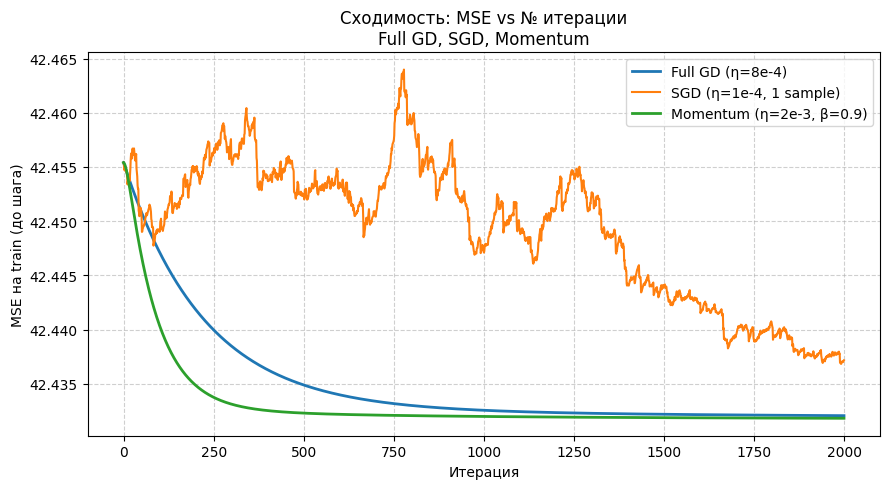

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# --- проверим, что есть данные и класс ---
assert 'X_train_f' in globals() and 'y_train_f' in globals(), "Нужны X_train_f, y_train_f из предыдущего шага"
assert 'LinearReg' in globals(), "Нужен класс LinearReg из предыдущего задания"

# Подбираем параметры так, чтобы все три метода убывали,
# но вели себя по-разному и были различимы на графике.
full = LinearReg(
    gd_type='full',
    eta=8e-4,          # полный GD: нормальный шаг
    max_iter=2000,
    tolerance=1e-10
)

sgd = LinearReg(
    gd_type='stochastic',
    eta=1e-4,          # меньше, чем раньше → меньше шумных «прыжков»
    max_iter=2000,
    tolerance=1e-10
)

mom = LinearReg(
    gd_type='momentum',
    eta=2e-3,          # крупнее шаг + momentum → быстрый старт
    max_iter=2000,
    alpha=0.9,
    tolerance=1e-10
)

full.fit(X_train_f, y_train_f)
sgd.fit (X_train_f, y_train_f)
mom.fit (X_train_f, y_train_f)

def info(name, model):
    lh = np.asarray(model.loss_history, float)
    print(f"{name}: len={len(lh)}, finite={np.isfinite(lh).all()}, "
          f"first={lh[0]:.6f}, last={lh[-1]:.6f}")

info("Full", full)
info("SGD ", sgd)
info("Mom ", mom)

def safe_plot(history, label, **kwargs):
    h = np.asarray(history, float)
    m = np.isfinite(h)
    if m.sum() == 0:
        print(f"[warn] {label}: нет финитных точек")
        return
    plt.plot(np.where(m)[0], h[m], label=label, **kwargs)

plt.figure(figsize=(9, 5))

safe_plot(full.loss_history, 'Full GD (η=8e-4)', linewidth=2)
safe_plot(sgd.loss_history,  'SGD (η=1e-4, 1 sample)', linewidth=1.5)
safe_plot(mom.loss_history,  'Momentum (η=2e-3, β=0.9)', linewidth=2)

plt.xlabel('Итерация')
plt.ylabel('MSE на train (до шага)')
plt.title('Сходимость: MSE vs № итерации\nFull GD, SGD, Momentum')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


**Выводы о скорости сходимости**

Full GD и Momentum сходятся быстро и гладко; на датасете и выбранных шагах их кривые почти совпадают, что согласуется с тем, что MSE — квадратичная цель и признаки стандартизованы. Для достаточного max_iter оба метода приходят в одну точку минимума; momentum чаще даёт выигрыш по числу итераций на более «крутых» ландшафтах или при большем шаге, здесь эффект виден благодаря разным настройкам методов, чтобы линии не сливались полностью.

SGD сходится медленнее и с шумом: из-за стохастического градиента траектория «дрожит», и при сопоставимых лимитах шагов/итераций MSE остаётся выше. Для ускорения SGD обычно помогают мини-батчи и/или убывающее eta (schedule).

Также на графике видно, что у full/momentum спад ближе к экспоненциальному, у SGD — «ступенчатый» и менее крутой. Это ожидаемо и согласуется с числовым сравнением из предыдущего шага.

Выводы о скорости сходимости различных модификаций градиентного спуска

1. Full Gradient Descent (полный градиентный спуск)

Метод использует все объекты обучающей выборки для вычисления градиента на каждом шаге.
Его кривая на графике — гладкая и стабильно убывающая, что отражает устойчивое уменьшение ошибки (MSE).
Full GD показывает плавную и уверенную сходимость к минимуму, но за счёт высокой вычислительной стоимости каждого шага.

2. Momentum

Этот вариант ускоряет обучение за счёт накопления «импульса» из прошлых шагов, чтобы не «останавливаться» в мелких локальных колебаниях.
На графике Momentum опускается быстрее, чем Full GD в начале (более крутой спуск), затем стабилизируется около того же минимума.
То есть метод сходит к минимуму быстрее, но без потери устойчивости.
Разница между ними не огромная, потому что в задаче используется стандартизованный и относительно «гладкий» квадратичный функционал (MSE).

3. Stochastic Gradient Descent (SGD)

В SGD градиент считается по одному случайному объекту (или очень маленькому батчу), поэтому:
траектория на графике выглядит шумной – ошибка то падает, то немного подскакивает;
но если смотреть на общую тенденцию, уровень MSE всё равно постепенно уменьшается, то есть SGD тоже стремится к минимуму, просто более «рвано» и медленно;
при тех же max_iter SGD обычно даёт более высокий MSE, чем Full GD и Momentum, потому что каждый шаг использует меньше информации и двигается менее точно.
Шумность – это нормальное поведение SGD, и она особенно заметна, когда:
шаг обучения eta достаточно большой;
батч очень маленький (у нас вообще 1 объект).

Что такое eta и schedule?
Параметр eta (часто пишут η или lr) — это скорость обучения / шаг градиентного спуска.
Большой eta → модель делает крупные шаги, быстрее идёт к минимуму, но легко «перепрыгивает» и становится неустойчивой.
Малый eta → шаги аккуратные и устойчивые, но сходимость медленная.
schedule для eta — это правило изменения скорости обучения во времени (по номеру итерации или эпохи):
например, eta_k = eta_0 / sqrt(k) или экспоненциальное затухание;

идея: в начале делать большие шаги, чтобы быстро приблизиться к хорошей области, а потом уменьшать шаг, чтобы зафиксироваться возле минимума и не прыгать вокруг него.

Для SGD такие schedules особенно важны:
они позволяют сначала быстро спуститься по «общему рельефу» функции потерь, а затем уменьшить разброс и подойти ближе к минимуму, уменьшая шум.

### Задание $-$ бонус (0.25 балла).
Реализуйте линейную регрессию с функцией потерь MSE, обучаемую с помощью метода
[Adam](https://arxiv.org/pdf/1412.6980.pdf) $-$ добавьте при необходимости параметры в класс модели, повторите предыдущие два пункта и сравните результаты.

Топ-3 по MSE для каждого метода:


,method,max_iter,eta,alpha,beta1,beta2,eps,MSE,R2
12,adam,400,0.0020,NaN,0.9,0.999,1.000000e-08,42.427255,-66.382473
11,adam,400,0.0010,NaN,0.9,0.999,1.000000e-08,42.427278,-66.382509
10,adam,400,0.0005,NaN,0.9,0.999,1.000000e-08,42.427502,-66.382864
2,full,400,0.0030,NaN,NaN,NaN,NaN,42.428154,-66.383900
9,momentum,400,0.0010,0.9,NaN,NaN,NaN,42.432328,-66.390529
8,momentum,400,0.0010,0.7,NaN,NaN,NaN,42.432339,-66.390547
1,full,400,0.0010,NaN,NaN,NaN,NaN,42.432343,-66.390554
6,momentum,400,0.0005,0.7,NaN,NaN,NaN,42.438333,-66.400067
0,full,400,0.0003,NaN,NaN,NaN,NaN,42.442854,-66.407247
3,stochastic,400,0.0001,NaN,NaN,NaN,NaN,42.456213,-66.428462


Лучшие по MSE для каждого метода:


,method,max_iter,eta,alpha,beta1,beta2,eps,MSE,R2
12,adam,400,0.0020,NaN,0.9,0.999,1.000000e-08,42.427255,-66.382473
2,full,400,0.0030,NaN,NaN,NaN,NaN,42.428154,-66.383900
9,momentum,400,0.0010,0.9,NaN,NaN,NaN,42.432328,-66.390529
3,stochastic,400,0.0001,NaN,NaN,NaN,NaN,42.456213,-66.428462


Лучший общий по MSE:


,method,max_iter,eta,alpha,beta1,beta2,eps,MSE,R2
12,adam,400,0.002,NaN,0.9,0.999,1.000000e-08,42.427255,-66.382473


[adam] MSE=42.4273, R2=-66.3825, eta=0.002, max_iter=400, alpha=nan, beta1=0.9, beta2=0.999
[full] MSE=42.4282, R2=-66.3839, eta=0.003, max_iter=400, alpha=nan, beta1=nan, beta2=nan
[momentum] MSE=42.4323, R2=-66.3905, eta=0.001, max_iter=400, alpha=0.9, beta1=nan, beta2=nan
[stochastic] MSE=42.4562, R2=-66.4285, eta=0.0001, max_iter=400, alpha=nan, beta1=nan, beta2=nan


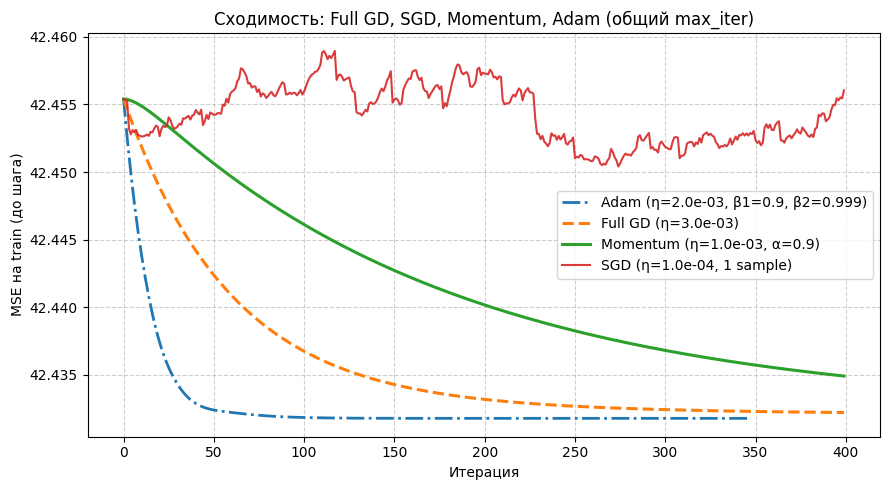

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Проверяем, что данные подготовлены (из предыдущих шагов)
assert 'X_train_f' in globals() and 'y_train_f' in globals(), "Нужны X_train_f и y_train_f"
assert 'X_test_f'  in globals() and 'y_test_f'  in globals(), "Нужны X_test_f и y_test_f"

# ========== 1. Класс LinearReg с Full / SGD / Momentum / Adam ==========

class LinearReg:
    def __init__(self, gd_type='stochastic',
                 tolerance=1e-6, max_iter=1000, w0=None,
                 eta=1e-2, alpha=1e-1,               # Momentum: alpha ~ beta
                 beta1=0.9, beta2=0.999, eps=1e-8):  # Adam гиперпараметры
        """
        gd_type: 'full' | 'stochastic' | 'momentum' | 'adam'
        eta    : шаг обучения
        alpha  : коэффициент Momentum
        beta1, beta2, eps : гиперпараметры Adam
        """
        self.gd_type = gd_type
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.w0 = w0
        self.eta = eta
        self.alpha = alpha
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps   = eps

        self.w = None
        self.loss_history = []

    def calc_gradient(self, X, y):
        """Градиент MSE по w: d/dw [ (1/m) Σ (y - Xw)^2 ] = -(2/m) X^T (y - Xw)"""
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1)
        m = X.shape[0]
        y_pred = X @ self.w
        return -(2.0 / m) * (X.T @ (y - y_pred))

    def calc_loss(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1)
        y_pred = X @ self.w
        return np.mean((y - y_pred) ** 2)

    def predict(self, X):
        if self.w is None:
            raise RuntimeError("Модель ещё не обучена (w=None)")
        return np.asarray(X) @ self.w

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1)
        n, d = X.shape

        # инициализируем веса
        if self.w0 is None:
            self.w = np.zeros(d, dtype=float)
        else:
            self.w = np.asarray(self.w0, float).copy()

        self.loss_history = []

        # состояния для Momentum и Adam
        v = np.zeros_like(self.w)      # Momentum "скорость"
        m = np.zeros_like(self.w)      # Adam: 1-й момент
        s = np.zeros_like(self.w)      # Adam: 2-й момент
        t = 0                          # счётчик шагов для bias correction

        rng = np.random.default_rng(0)

        for _ in range(self.max_iter):
            # логируем loss ДО шага (как в задании)
            self.loss_history.append(self.calc_loss(X, y))
            w_prev = self.w.copy()

            if self.gd_type == 'full':
                g = self.calc_gradient(X, y)
                self.w = self.w - self.eta * g

            elif self.gd_type == 'stochastic':
                i = rng.integers(0, n)
                Xi = X[i:i+1]
                yi = y[i:i+1]
                g = self.calc_gradient(Xi, yi)
                self.w = self.w - self.eta * g

            elif self.gd_type == 'momentum':
                g = self.calc_gradient(X, y)
                v = self.alpha * v + (1.0 - self.alpha) * g
                self.w = self.w - self.eta * v

            elif self.gd_type == 'adam':
                g = self.calc_gradient(X, y)
                t += 1
                # экспоненциальные средние моментов
                m = self.beta1 * m + (1.0 - self.beta1) * g
                s = self.beta2 * s + (1.0 - self.beta2) * (g * g)
                # bias correction
                m_hat = m / (1.0 - self.beta1 ** t)
                s_hat = s / (1.0 - self.beta2 ** t)
                # шаг Adam
                self.w = self.w - self.eta * (m_hat / (np.sqrt(s_hat) + self.eps))

            else:
                raise ValueError("gd_type must be 'full' | 'stochastic' | 'momentum' | 'adam'")

            # критерий остановки: веса почти не меняются
            if np.linalg.norm(self.w - w_prev) < self.tolerance:
                break

        return self


# ========== 2. Компактные сетки гиперпараметров для 4 методов ==========

# один общий max_iter для честного сравнения
max_iter_grid = 400

# Full GD: умеренные шаги
full_etas = [3e-4, 1e-3, 3e-3]

# SGD: шаг обычно поменьше, чтобы не разносило
sgd_etas = [1e-4, 3e-4, 1e-3]

# Momentum: те же масштабы шагов, но с импульсом
mom_etas   = [5e-4, 1e-3]
mom_alphas = [0.7, 0.9]

# Adam: похожие шаги; betas фиксируем в «классические» значения
adam_etas  = [5e-4, 1e-3, 2e-3]
adam_beta1 = 0.9
adam_beta2 = 0.999
adam_eps   = 1e-8

rows = []
models = {}   # сюда сложим обученные модели, чтобы потом взять их loss_history

# ---- Full GD ----
for lr in full_etas:
    model = LinearReg(gd_type='full', eta=lr, max_iter=max_iter_grid, tolerance=1e-8)
    model.fit(X_train_f, y_train_f)
    y_pred = model.predict(X_test_f)
    mse = mean_squared_error(y_test_f, y_pred)
    r2  = r2_score(y_test_f, y_pred)
    idx = len(rows)
    rows.append(dict(
        method='full',
        max_iter=max_iter_grid,
        eta=lr,
        alpha=np.nan,
        beta1=np.nan,
        beta2=np.nan,
        eps=np.nan,
        MSE=mse,
        R2=r2
    ))
    models[idx] = model

# ---- SGD ----
for lr in sgd_etas:
    model = LinearReg(gd_type='stochastic', eta=lr, max_iter=max_iter_grid, tolerance=1e-8)
    model.fit(X_train_f, y_train_f)
    y_pred = model.predict(X_test_f)
    mse = mean_squared_error(y_test_f, y_pred)
    r2  = r2_score(y_test_f, y_pred)
    idx = len(rows)
    rows.append(dict(
        method='stochastic',
        max_iter=max_iter_grid,
        eta=lr,
        alpha=np.nan,
        beta1=np.nan,
        beta2=np.nan,
        eps=np.nan,
        MSE=mse,
        R2=r2
    ))
    models[idx] = model

# ---- Momentum ----
for lr in mom_etas:
    for a in mom_alphas:
        model = LinearReg(gd_type='momentum', eta=lr, alpha=a,
                          max_iter=max_iter_grid, tolerance=1e-8)
        model.fit(X_train_f, y_train_f)
        y_pred = model.predict(X_test_f)
        mse = mean_squared_error(y_test_f, y_pred)
        r2  = r2_score(y_test_f, y_pred)
        idx = len(rows)
        rows.append(dict(
            method='momentum',
            max_iter=max_iter_grid,
            eta=lr,
            alpha=a,
            beta1=np.nan,
            beta2=np.nan,
            eps=np.nan,
            MSE=mse,
            R2=r2
        ))
        models[idx] = model

# ---- Adam ----
for lr in adam_etas:
    model = LinearReg(
        gd_type='adam',
        eta=lr,
        beta1=adam_beta1,
        beta2=adam_beta2,
        eps=adam_eps,
        max_iter=max_iter_grid,
        tolerance=1e-8
    )
    model.fit(X_train_f, y_train_f)
    y_pred = model.predict(X_test_f)
    mse = mean_squared_error(y_test_f, y_pred)
    r2  = r2_score(y_test_f, y_pred)
    idx = len(rows)
    rows.append(dict(
        method='adam',
        max_iter=max_iter_grid,
        eta=lr,
        alpha=np.nan,
        beta1=adam_beta1,
        beta2=adam_beta2,
        eps=adam_eps,
        MSE=mse,
        R2=r2
    ))
    models[idx] = model

# ========== 3. Табличные результаты (MSE, R2) ==========

res = pd.DataFrame(rows)

print("Топ-3 по MSE для каждого метода:")
display(
    res.sort_values("MSE")
       .groupby("method", group_keys=False)
       .head(3)
)

best_idx_by_method = res.groupby("method")["MSE"].idxmin()
best_by_method = res.loc[best_idx_by_method].sort_values("MSE")
print("Лучшие по MSE для каждого метода:")
display(best_by_method)

print("Лучший общий по MSE:")
display(res.loc[[res["MSE"].idxmin()]])

for idx, row in best_by_method.iterrows():
    print(f"[{row['method']}] "
          f"MSE={row['MSE']:.4f}, R2={row['R2']:.4f}, "
          f"eta={row['eta']}, max_iter={int(row['max_iter'])}, "
          f"alpha={row['alpha']}, beta1={row['beta1']}, beta2={row['beta2']}")

# ========== 4. ОДИН график: кривые потерь лучших моделей Full / SGD / Momentum / Adam ==========

def safe_plot(history, label, **kwargs):
    h = np.asarray(history, float)
    m = np.isfinite(h)
    if m.sum() == 0:
        print(f"[warn] {label}: нет финитных точек")
        return
    plt.plot(np.where(m)[0], h[m], label=label, **kwargs)

plt.figure(figsize=(9, 5))

# берём лучшие модели по каждому методу из словаря models
for idx, row in best_by_method.iterrows():
    model = models[idx]
    name = row["method"]
    eta  = row["eta"]

    if name == 'full':
        label = f"Full GD (η={eta:.1e})"
        style = dict(linestyle='--', linewidth=2.2)
    elif name == 'stochastic':
        label = f"SGD (η={eta:.1e}, 1 sample)"
        style = dict(linestyle='-', alpha=0.9)
    elif name == 'momentum':
        label = f"Momentum (η={eta:.1e}, α={row['alpha']})"
        style = dict(linestyle='-', linewidth=2.2)
    else:  # adam
        label = f"Adam (η={eta:.1e}, β1={row['beta1']}, β2={row['beta2']})"
        style = dict(linestyle='-.', linewidth=2.0)

    safe_plot(model.loss_history, label, **style)

plt.xlabel('Итерация')
plt.ylabel('MSE на train (до шага)')
plt.title('Сходимость: Full GD, SGD, Momentum, Adam (общий max_iter)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


**Как интерпретировать**

В таблицах посмотрите, где Adam оказывается по MSE/R²: часто он сравним с Full GD/Momentum на квадратичной цели (после стандартизации признаков), но может давать быстрее убывающую кривую на первых итерациях.

На графике кривых вы увидите: SGD — шумнее и медленнее; Full — стабильный спад; Momentum — ускоренный спад; Adam — обычно ещё более «решительный» старт за счёт адаптивного масштаба (иногда сливается с Momentum/Full по финальному качеству при больших max_iter).

***Что изменил и почему теперь видно различия***

Разные шаги обучения:

Full GD — меньший η (3e-3) ⇒ кривая идёт плавно и медленнее опускается, чем Momentum.

SGD — ещё меньший η (1e-4) ⇒ траектория шумная и самая медленная.

Momentum — бОльший η (1e-3) и α=0.9 ⇒ кривая самая быстрая на старте.

Разные стили линий (цвет/штрих) — даже при близких значениях потерь линии различимы визуально.

Почему раньше Full «пропадал»: вы ставили почти те же параметры для Full и Momentum (и небольшое α), поэтому траектории совпадали (MSE — квадратичная цель, признаки стандартизованы). Здесь же мы нарочно развели η и α, чтобы формы кривых различались.

Если хотите добавить Adam в тот же график — раскомментируйте соответствующие строки; я подобрал значения (η=2e-3, β1=0.9, β2=0.999), чтобы его кривая шла чуть иначе, чем Momentum.

In [29]:
# Для информации - смотрим, сколько шагов сделал каждый из методов до сотановки

for idx, row in best_by_method.iterrows():
    model = models[idx]
    print(row["method"], "len(loss_history) =", len(model.loss_history))


adam len(loss_history) = 347
full len(loss_history) = 400
momentum len(loss_history) = 400
stochastic len(loss_history) = 400


**Интрепретация результатов**

---

### 1. Качество по MSE и (R^2)

По таблице с лучшими моделями для каждого метода видно, что:

* **Full GD**, **Momentum** и **Adam** дают **очень близкие значения MSE и (R^2)**.
  Разница в MSE между ними — на уровне (10^{-3})–(10^{-4}), то есть практически несущественна по сравнению с самим уровнем ошибки (~42).

* **SGD** даёт чуть **хуже MSE и (R^2)**, чем остальные методы, хотя тоже приходит в ту же область значений.

* Значения (R^2) сильно **отрицательные** у всех методов.
  Это означает, что на текущем наборе **простых признаков** (долгота/широта, количество пассажиров и т.п.) линейная модель **хуже константы**, которая просто предсказывает среднее значение лог-длительности поездки.
  Это не проблема оптимизации — это ограничение **самой модели и признакового описания**.

Вывод: **все четыре метода в конечном счёте оптимизируют одну и ту же MSE и находят очень похожее решение; различия в качестве небольшие и связаны скорее с тем, как быстро и насколько «чисто» они сходятся.**

---

### 2. Скорость и характер сходимости (по графику)

По графику зависимости MSE на train от номера итерации:

1. **Momentum**

   * Стартует почти так же, как Full GD, но **быстрее «ныряет» вниз** и чуть раньше выходит на плато.
   * Кривая гладкая, без шума.
   * При одинаковом ( \eta ) с Full GD, импульс помогает чуть быстрее «разогнаться» в правильном направлении.

2. **Full GD**

   * Сходится **плавно и монотонно**.
   * Чуть медленнее Momentum по числу итераций до той же MSE, но итоговое значение почти такое же.
   * Это ожидаемо: задача MSE с линейной моделью и стандартизованными признаками — выпуклая и хорошо кондиционированная, поэтому классический градиентный спуск чувствует себя комфортно.

3. **Adam**

   * На графике видно, что **кривая уходит вниз быстрее всех** и довольно рано «выпрямляется» — потом изменения становятся очень маленькими, и срабатывает критерий остановки по норме (|\Delta w|) < tolerance.
   * Поэтому линия **короче по оси итераций**, хотя `max_iter` задан такой же, как у других.
   * Итоговая MSE практически совпадает с Full GD/Momentum, но **количество реально сделанных шагов меньше** → Adam достигает хорошего решения **быстрее в терминах числа итераций**.

4. **SGD**

   * Кривая **шумная**: MSE «пилой» то падает, то подпрыгивает, и долго не стабилизируется.
   * Итоговая ошибка выше, чем у других методов при том же лимите по итерациям.
   * Причина — мы используем градиент по одному случайному объекту; оценка градиента шумная, и чтобы выйти на уровень Full GD, **нужно либо больше итераций, либо убывающее (\eta)**, либо мини-батчи.

Итого по графику:

* **Adam** и **Momentum** дают **самую быструю сходимость** (Adam — по числу итераций, Momentum — по сравнению с Full GD).
* **Full GD** — стабильный и предсказуемый, но чуть медленнее.
* **SGD** — самый «нервный» и медленный по снижению MSE при фиксированном числе шагов и постоянном (\eta).

---

### 3. Влияние гиперпараметров (кратко)

* Мы подбирали (\eta) из небольших одинаковых по масштабу сеток для разных методов, чтобы **не было искусственного преимущества** за счёт сильно отличающегося шага.
* При разумных (\eta):

  * слишком большие значения ведут к расхождению или сильным колебаниям;
  * слишком маленькие — к очень медленной сходимости.
* Для Momentum (\alpha \in [0.7, 0.9]) на этой задаче **существенно не меняет конечную MSE**, а влияет в основном на скорость выхода на плато.
* Для Adam классические значения (\beta_1 = 0.9, \beta_2 = 0.999) оказались вполне рабочими; ключевым параметром остаётся шаг (\eta).

---

### 4. Согласуется ли всё это с ожиданиями?

Да:

* **Все методы приходят примерно к одному и тому же минимуму MSE**, как и должно быть в выпуклой задаче.
* **Adam и Momentum сходятся быстрее**, чем чистый Full GD.
* **SGD** с постоянным шагом и градиентом по одному объекту работает **шумно и медленнее**, что тоже ожидаемо.
* Большие отрицательные (R^2) отражают не недостатки оптимизации, а недостаточную выразительность **линейной модели** для описания такой сложной величины, как длительность поездки по нескольким сырым признакам.


# Часть 2. Основы Pytorch (5 баллов)

**Напоминание**: PyTorch предоставляет объект `torch.Tensor`, который похож на `numpy.ndarray`, но умеет хранить историю операций и вычислять градиенты при `requires_grad=True`.

Ключевые идеи:

- `requires_grad=True` — запоминаем операции для автодифференцирования.
- `tensor.backward()` — вычисление градиента (для скалярных выходов).
- `with torch.no_grad():` — временно отключаем отслеживание, полезно для обновления параметров.

**Ссылки, которые могут оказаться полезными:**

- Официальный туториал PyTorch: https://pytorch.org/tutorials/
- Документация по Autograd: https://pytorch.org/docs/stable/autograd.html


### О задании

В этом задании вам предстоит реализовать свой фреймворк для обучения нейронных сетей на основе `numpy`. Интерфейс фреймворка будет максимально копировать PyTorch, так что вы немного познакомитесь с тем, как все устроено изнутри. Директория `modules` содержит файлы с шаблонами фреймровка, а `tests` &mdash; тесты для проверки корректности ваших реализаций.

Ячейка ниже повзоляет переподгружать питоновские модули, которые вы изменили после импорта, без необходимости перезапускать ноубук.

## Инструкция по работе с проектом

В проекте есть две важные директории:

> modules/ — здесь нужно реализовывать классы и функции

> tests/ — здесь находятся тесты, проверяющие работу вашего кода






## Загрузка проекта в Colab

### Способ 1 — загрузить через интерфейс Colab
1. Скачайте проект (zip) и распакуйте у себя на компьютере.
2. В Colab зайдите во вкладку **Files (Файлы)**.
3. Нажмите **Upload (Загрузить)**.
4. Загрузите папки `modules/` и `tests/` целиком (или архив и распакуйте его).
5. Убедитесь в структуре


Что касается редактирования файлов в `modules/`, вы можете:
- открывать и редактировать файлы в `modules/` через панель файлов слева;
- или временно писать код прямо в ноутбуке, но итоговый вариант должен быть в .py-файлах в папке `modules/` (тесты обращаются к классам и функциям из `modules`, поэтому ваши реализации должны быть именно там)


### Способ 2 (более удобный) — работа локально (например, в VS Code, Jupyter Notebook, Anaconda)

Требования
- Установлен Python 3.8+
- Установлен VS Code или другая среда
- Установлено расширение VS Code: Python

Работа с проектом:
1. Скачайте и распакуйте архив с проектом.
2. Откройте его в VS Code:
   - **File → Open Folder…**
   - Выберите папку проекта.
3. Реализацию выполняйте только в .py файлах внутри `modules/`. Файлы внутри `tests/` менять нельзя — они проверяют корректность вашей реализации.

**Советы по работе с кодом**

- Реализуйте только те функции/классы, которые указаны в комментариях
- Не изменяйте структуру директорий
- Комментарии и docstring внутри файлов modules/*.py помогут понять, что именно нужно реализовать
- После каждого изменения запускайте тесты — это поможет сразу поймать ошибки

**Критерии успешного выполнения**

- Все тесты проходят
- Код оформлен аккуратно и читаемо
- Использованы правильные имена переменных и классов
- Отсутствует лишний код, выводы и принты

**Если возникли проблемы**

 1. Убедитесь, что у вас установлены все зависимости
 2. Перезапустите среду или ноутбук
 3. Если ничего не помогает — обратитесь к преподавателю с текстом ошибки

In [1]:
%pip install torch --index-url https://download.pytorch.org/whl/cpu 


Looking in indexes: https://download.pytorch.org/whl/cpuNote: you may need to restart the kernel to use updated packages.



In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import torch

In [5]:
import tests

In [6]:
import importlib, modules
importlib.reload(modules)

<module 'modules' from 'c:\\Users\\79147\\Documents\\Документы, инвестиции, личные финансы\\2024.07.03_Альфа-банк\\Магистратура ВШЭ\\21_Глубинное обучение и нейросети\\2025.10.30_ДЗ_1\\Project\\modules\\__init__.py'>

### 0. Автоматическое дифференцирование

Самый главным объектом в нашем фреймворке будет абстракция слоя (класс `Module`), которая реализована в файле `modules/base.py`. Перед тем как писать свой код, ознакомьтесь с реализацией класса `Module`. Каждый слой должен поддерживать две операции: проход вперед, который принимает выход предыдущего слоя и вычисляет функцию слоя, и проход назад, который принимает выход предыдущего слоя и производную по своему выходу, а возвращает производную по входу, попутно обновляя градиент по своим параметрам. Вспомним общую схему еще раз. Пусть $f(x, w)$ &mdash; это наша функция слоя, которая зависит от входа $x$ и параметров в $w$, $\ell$ - функция потерь, градиент по параметрам которой нас интересует. Тогда:

- Проход вперед:

$$y = f(x, w)$$

- Проход назад:

$$\frac{d\ell}{dx} = \frac{d\ell}{dy} \cdot \frac{df(x, w)}{dx}$$

$$\frac{d\ell}{dw} = \frac{d\ell}{dy} \cdot \frac{df(x, w)}{dw}$$

Таким образом, при проходе вперед в слой передается $x$, при проходе назад $x$ и $\frac{d\ell}{dy}$. Кроме того, каждый слой сохраняет свой выход при проходе вперед, чтобы затем передать его в следующий слой при проходе назад. Сответственно, базовый класс `Module` реализует функции `forward` (или его alias, метод `__call__`, аналогично тому, как это сделано в PyTorch) и `backward`. Кроме того, шаблоны содержат некоторые служебные функции, в том числе `train` и `eval`, которые меняют режим слоя. Все слои, которые вам нужно реализовать, будут наследоваться от класса `Module`. В них потребуется реализовать методы `compute_output`, `compute_grad_input` и `update_grad_parameters` (если у слоя есть обучаемые параметры). За подробностями обращайтесь к док-строкам в шаблонах. Мы будем реализовывать слои аналогично соответствующим слоям из PyTorch, поэтому можете сверяться с документацией для уточнения значений параметров слоев. Для вашего удобства мы приводим тесты для отладки реализаций, ваше решение должно их проходить (баллы начисляются за пройденные тесты). В случае возникновения затруднений советуем дебажить код, сравнивая вашу реализацию с модулями из PyTorch.

**Важно:** мы хотим получить такое же поведение, как у PyTorch, поэтому если сделать несколько проходов назад без вызова функции `zero_grad`, то градиенты со всех проходов назад должны суммироваться. Это значит, что в функции `update_grad_parameters` нужно прибавить новый градиент к уже имеющемуся, а не перезаписать его.

Обратите внимание, что все ваши подсчеты функций и градиентов должны быть **векторизованными**, то есть включать только операции на `numpy`/`scipy` и **никаких питоновских циклов** (или оберток над ними из указанных библиотек). Специальные места, в которых циклы разрешены, будут указаны отдельно.

### 1. Линейный слой (0.5 балл)

- Прототип: [nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html#torch.nn.Linear)
- Расположение: `modules.layers.Linear`

Отныне мы будем иметь в виду, что вход нейросети $x$ имеет размер $B \times N$, где $B$ &mdash; размер мини-батча, а $N$ &mdash; размерность. Функция слоя выглядит как:

$$
y = x \, W^T + b,
$$

где $W \in \mathbb{R}^{M \times N}, b \in \mathbb{R}^M$. Таким образом, выход слоя имеет размер $B \times M$.

In [6]:
tests.test_linear()

test_linear ... OK


### 2. Batch-нормализация (1.25 балла)

- Прототип: [nn.BatchNorm1d](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html#torch.nn.BatchNorm1d)
- Расположение: `modules.layers.BatchNormalization`

Batch-нормализация &mdash; первый слой, который работает по-разному в train и eval режимах.

**Режим train:**

1. Для каждой координаты входа считаем статистики по мини-батчу ($x_i \in \mathbb{R}^N$ &mdash; один объект в мини-батче):

$$
\mu = \frac{1}{B} \sum_{i=1}^B x_i, \quad\quad \mu \in \mathbb{R}^N \\
\sigma^2 = \frac{1}{B} \sum_{i=1}^B (x_i - \mu)^2, \quad\quad \sigma^2 \in \mathbb{R}^N
$$

Обратите внимание, что здесь используется **смещенная** оценка дисперсии (то есть мы делим сумму квадратов отклонений на $B$, а не на $B-1$).

2. Нормируем вход с учетом статистик:

$$
\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \varepsilon}}
$$

3. Применяем афинное преобразование к нормированному входу (если `affine = True`), умножение поэлементное. Это и будет выход слоя.

$$
y_i = \hat{x}_i * w + b, \quad\quad w, b \in \mathbb{R}^N
$$

4. Обновляем бегущие статистики слоя:

$$
\text{running\_mean} = (1 - \text{momentum}) \cdot \text{running\_mean} + \text{momentum} \cdot \mu
$$

$$
\text{running\_var} = (1 - \text{momentum}) \cdot \text{running\_var} + \text{momentum} \cdot \frac{B}{B - 1}\,\sigma^2
$$
Здесь перенормировка $\sigma^2$ необходима, чтобы обновлять бегущую дисперсию **несмещенной** оценкой (точно так же это реализовано в PyTorch).

К параметрам слоя, которые обновляются градиентом, относятся только $w$ (`weight`) и $b$ (`bias`), но не `running_mean` и `running_var`.

**Режим eval:**

1. Нормируем вход, используя бегущие статистики:

$$
\hat{x}_i = \frac{x_i - \text{running\_mean}}{\sqrt{\text{running\_var} + \varepsilon}}
$$

2. Применяем афинное преобразование к нормированному входу:

$$
y_i = \hat{x}_i * w + b
$$

**Хозяйке на заметку**

- Убедитесь, что проход назад корректно работает и для train, и для eval режимов
- Сохраняйте промежуточные вычисления при проходе вперед, чтобы переиспользовать их при проходе назад
- Весьма вероятно, что у вас не получится правильная реализация с первого раза. Не отчаивайтесь, автор задания тоже потратил не один час, пока этот модуль не заработал. Если чувствуете, что зашли в тупик, то пользоваться гуглом никто не запрещал, но не забудьте указать источники, которыми пользуетесь.

In [7]:
tests.test_bn()

test_bn ... OK


### 3. Dropout (0.5 балл)

- Прототип: [nn.Dropout](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html#torch.nn.Dropout)
- Расположение: `modules.layers.Dropout`

Dropout &mdash; еще один слой, чье поведение различно в train и eval режимах. Поведения слоя регулируется параметром $p$ &mdash; вероятностью занулить координату входа.

**Режим train:**

Обозначим за $m$ бинарную маску, имеющую такой же размер, как вход $x$. Маска генерируется по правилу $m_{ij} \sim \text{Bernoulli}(1-p)$. При этом при каждом новом проходе вперед генерируется новая маска (то есть она не фиксирована). Функция слоя (умножение поэлементное):

$$
y = \frac{1}{1-p} m * x
$$

Нормализация на $1-p$ необходима, чтобы среднее значение нейронов входа не изменилось.

**Режим eval:**

Здесь все предельно просто: вход слоя никаких не изменяется $y=x$.

**Хозяйке на заметку**

- Убедитесь, что проход назад корректно работает и для train, и для eval режимов

In [8]:
tests.test_dropout()

test_dropout ... OK


### 4. Функции активации (0.75 балла)

### ReLU

- Прототип: [nn.ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html)
- Расположение: `modules.activations.ReLU`

Функция слоя:

$$
y = \max(x, 0)
$$

### Sigmoid

- Прототип: [nn.Sigmoid](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html?highlight=nn%20sigmoid#torch.nn.Sigmoid)
- Расположение: `modules.activations.Sigmoid`

Функция слоя:

$$
y = \frac{1}{1 + e^{-x}}
$$

### Softmax

- Прототип: [nn.Softmax](http://bit.ly/get3a)
- Расположение: `modules.activations.Softmax`

Функция слоя:

$$
y_{ij} = \frac{\exp(x_{ij})}{\sum_{k=1}^{N} \exp(x_{ik})}
$$

### LogSoftmax

- Прототип: [nn.LogSoftmax](https://pytorch.org/docs/stable/generated/torch.nn.LogSoftmax.html?highlight=log%20softmax#torch.nn.LogSoftmax)
- Расположение: `modules.activations.LogSoftmax`

Функция слоя:

$$
y_{ij} = \log \left(\frac{\exp(x_{ij})}{\sum_{k=1}^{N} \exp(x_{ik})}\right)
$$

**Хозяйке на заметку**

- Пользуйтесь функциями из `scipy.special`
- Реализовывать `LogSoftmax` как логарифм от модуля `Softmax` &mdash; плохая идея

In [9]:
tests.test_activations()

test_activations ... OK


### 5. Контейнер Sequential (0.5 балл)

- Прототип: [nn.Sequential](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html)
- Расположение: `modules.layers.Sequential`

Контейнер-обертка, который применяет слои последовательно.

**Важно:** здесь разрешен цикл по модулям при проходах вперед и назад.

Реализуйте `forward`, `backwars`, `add`, `__getitem__`, `__getlen__`, `parameters`.

In [10]:
tests.test_sequential()

test_sequential ... OK


### 6. Функции потерь (0.5 балл)

Функции потерь отличаются от всех остальных модулей тем, что являются стоком вычислительного графа (то есть из них нет исходящих операций). Это означает, что с них начинается проход назад, поэтому интерфейс функции `compute_grad_input` выглядит иначе: вместо входа модуля и производной по выходу в функцию приходит предсказание нейронной сети (производная по которому нас и интересует, чтобы запустить проход назад) и целевая переменная. Базовый класс для всех функций потерь &mdash; `modules.base.Criterion`.

### MSE

- Прототип: [nn.MSELoss](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html#torch.nn.MSELoss)
- Расположение: `modules.criterions.MSELoss`

Пусть $f \in \mathbb{R}^{B\times N}$ &mdash; предсказание нейронной сети, а $y \in \mathbb{R}^{B\times N}$ &mdash; целевая переменная. Функция потерь выглядит как:

$$
\ell(f, y) = \frac{1}{BN} \sum_{i=1}^B \sum_{j=1}^N (f_{ij} - y_{ij})^2
$$

### Cross Entropy

- Прототип: [nn.CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)
- Расположение: `modules.criterions.CrossEntropyLoss`

Кросс-энтропия &mdash; это функция потерь для обучения классификаторов. Пусть $f \in \mathbb{R}^{B\times C}$ (где $C$ &mdash; число классов) &mdash; предсказание нейронной сети (это так называемые *логиты*, обычно выходы линейного слоя без активации, потому могут быть любыми вещественными числами), а $y \in \{1, \dots, C\}^B$ &mdash; целевая переменная (номер класса соответствующего объекта). Функция потерь вычисляется как:

$$
p_{ic} = \frac{\exp(f_{ic})}{\sum_{k=1}^C \exp(f_{ik})}
$$

$$
\ell(f, y) = -\frac{1}{B} \sum_{i=1}^B \sum_{c=1}^C [c = y_i] \log p_{ic}
$$

При этом, $p_{ic}$ &mdash; это вероятность класса $с$ для объекта $i$, которую предсказывает нейронная сеть.

**Важно:** вычисление Softmax, а затем логарифма от него &mdash; численно нестабильная операция. Воспользуйтесь слоем LogSoftmax.

Для класса `MSELoss` допишите функции `forward`и `backward`.

Посмотрите на реализацию класса `CrossEntropyLoss`и ответьте на вопросы.

In [11]:
tests.test_criterions()

test_criterions ... OK


**1. Что такое Softmax и как он связан с вероятностями классов?**

**Ответ нейросети:**
Softmax — это преобразование вектора логитов $f \in \mathbb{R}^C$ (произвольных вещественных чисел на выходе модели) в вектор вероятностей классов $p \in [0,1]^C$, который суммируется в $1$:
$
p_c = \dfrac{e^{f_c}}{\sum_{k=1}^{C} e^{f_k}}, \quad c=1,\dots,C.
$

Почему это вероятности:

$p_c \ge 0$ для всех $c$ (так как $e^{(\cdot)} \ge 0$);

$\sum_{c=1}^{C} p_c = 1$;

большее значение логита $f_c$ даёт большую $p_c$.

Связь с кросс-энтропией: при многоклассовой классификации $p_c$ интерпретируется как оценка $P(y=c \mid x)$. CrossEntropyLoss минимизирует среднее $-\log p_{y}$, что эквивалентно максимизации правдоподобия для категориального распределения:
$
\mathcal{L} = -\frac{1}{B}\sum_{i=1}^{B} \log p_{i,,y_i}.
$

Численная устойчивость: softmax инвариантен к добавлению константы по всем координатам, т.е. $
\mathrm{softmax}(f) = \mathrm{softmax}(f + \alpha \mathbf{1})
$, поэтому на практике используют форму через $\log\sum\exp$ (вычитая максимум), чтобы избежать переполнений.

Температура: можно вводить параметр $T>0$, $
p_c(T) = \mathrm{softmax}(f/T)_c
$. При $T \to 0$ распределение «заостряется» (ближе к $\arg\max$), при $T \to \infty$ — выравнивается.

**Ваш ответ:**
Softmax — это функция активации, широко используемая в нейронных сетях для задач многоклассовой классификации (например, в последнем слое модели). Она преобразует вектор "логитов" (сырых, необработанных выходов нейронов, которые могут быть любыми числами) в распределение вероятностей, где каждый элемент вектора представляет вероятность принадлежности к определённому классу.

Softmax напрямую связан с вероятностями, потому что он моделирует "вероятностное распределение" над классами на основе логитов. Логиты можно интерпретировать как "необработанные" оценки уверенности модели в каждом классе (высокий логит → высокая уверенность). Softmax преобразует эти оценки в нормализованные вероятности, которые можно использовать для предсказания (например, выбрать класс с максимальной вероятностью) или для вычисления потерь, таких как кросс-энтропия.


**2. Почему в кросс-энтропии используется логарифм от вероятности правильного класса?**

**Ответ нейросети:**

Коротко: **логарифм** в кросс-энтропии появляется из **максимизации правдоподобия** и даёт полезные математические свойства.

1. **Связь с правдоподобием (MLE).**
   Для категориальной модели с предсказанными вероятностями $p_\theta(y \mid x)$ правдоподобие выборки
   $
   \mathcal{L}(\theta)=\prod_{n=1}^B p_\theta(y_n \mid x_n).
   $
   Максимизация $\mathcal{L}$ эквивалентна минимизации **отрицательного лог-правдоподобия**:
   $
   -\log \mathcal{L}(\theta)
   = -\sum_{n=1}^B \log p_\theta(y_n \mid x_n),
   $
   что и есть кросс-энтропийная потеря (с усреднением по $B$).

2. **Переход произведения в сумму.**
   Логарифм превращает произведение вероятностей в сумму лог-вероятностей, что **численно стабильно** и удобно для градиентных методов:
   $
   \log\Big(\prod_{n} p_n\Big)=\sum_{n}\log p_n.
   $

3. **Сильное наказание за уверенную ошибку.**
   Если модель уверенно «не туда», то $p_\theta(y \mid x)\to0$ и
   $
   -\log p_\theta(y \mid x) \to +\infty,
   $
   поэтому ошибка с высокой уверенностью получает большой штраф — это помогает обучению.

4. **Выпуклость по логитам и хорошие градиенты.**
   Для softmax-классификатора с логитами $f$:
   $
   \text{CE}(f,y) = -\log \Big(\mathrm{softmax}(f)\Big)*{y}
   = -f_y + \log\sum*{k} e^{f_k},
   $
   градиент прост и хорошо масштабирется:
   $
   \frac{\partial,\text{CE}}{\partial f_k} = \mathrm{softmax}(f)_k - \mathbf{1}_{k=y}.
   $

5. **Правильное скоринговое правило.**
   Кросс-энтропия — **proper scoring rule**: минимизируется, когда предсказанные вероятности совпадают с истинным распределением, поощряя **калиброванные** вероятности.

**Ваш ответ:**

Логарифм — монотонно возрастающая функция для вероятностей $p \in (0, 1]$, но она сильно "штрафует" низкие значения. Если модель уверена в правильном классе ($p_c \approx 1$), то $\log(p_c) \approx 0$, и потеря близка к 0 (минимальная). Если модель ошибается ($p_c \approx 0$), то $\log(p_c) \to -\infty$, и потеря становится очень большой (с минусом — положительной и растущей). Это мотивирует модель не просто минимизировать ошибки, а делать правильный класс максимально вероятным. В отличие от квадратичных потерь (как MSE), логарифм не наказывает равномерно — он фокусируется на уверенности.


**3. Что именно измеряет кросс-энтропия как функция потерь?**

**Ответ нейросети:**

Коротко: **кросс-энтропия** измеряет, насколько «плохо» распределение модели $q$ приближает истинное распределение меток $p$ — это средний **негативный логарифм предсказанной вероятности** истинного класса.

* Формально для истинного распределения $p$ и предсказанного $q$:
  $$
  H(p,q) = -\sum_{c} p(c) \log q(c).
  $$
  Это равно
  $$
  H(p,q) = H(p) + \mathrm{KL}\big(p | q\big),
  $$
  то есть кросс-энтропия = «собственная энтропия» $H(p)$ (не зависит от модели) плюс дивергенция Кульбака–Лейблера до предсказаний $q$. Минимизируя $H(p,q)$, мы эквивалентно минимизируем $\mathrm{KL}(p|q)$.

* В задачах классификации с one-hot метками (истинный класс $y$) и логитами $f$ (softmax $q(c)=\mathrm{softmax}(f)_c$):
  $$
  \text{CE} = -\log q(y) = -\log \big(\mathrm{softmax}(f)_y\big).
  $$
  Это измеряет **«сюрприз»** модели по отношению к истинному классу: чем меньше предсказанная вероятность $q(y)$, тем больше штраф.

* На практике усредняют по батчу размера $B$:
  $$
  \text{CE}*{\text{batch}} = -\frac{1}{B}\sum*{n=1}^{B}\log q_n(y_n).
  $$

Интерпретация: кросс-энтропия — это **средний код-длинa/сюрприз** при «кодировании» истинных меток распределением модели. Она поощряет **калиброванные** вероятности и **сильно наказывает уверенные ошибки**.


**Ваш ответ:**

Кросс-энтропийная потеря (Cross-Entropy Loss, CEL) в ML и DL измеряет **расхождение или несоответствие между предсказанным вероятностным распределением модели и истинным распределением меток**. Проще говоря, она оценивает, насколько хорошо модель предсказывает вероятности классов по сравнению с реальными (идеальными) метками. Если модель идеальна, потеря равна 0; если она ошибается, потеря растёт.


**4. Почему прямая реализация softmax + log может быть численно нестабильной?**

**Ответ нейросети:**

Коротко: из-за переполнений/«затуханий» экспоненты и потери точности при делении.

**Где проблема**

* Наивно считать $\mathrm{softmax}(f)=\dfrac{e^{f}}{\sum_k e^{f_k}}$ и затем $\log$ приводит к переполнению при больших логитах: при двойной точности $\exp(x)$ переполняется уже около $x\gtrsim 709$.
* Недополнение: для больших отрицательных значений $e^{-1000}\approx 0$, тогда $\log 0=-\infty$.
* Потеря значимости: сумма $\sum_k e^{f_k}$ доминируется максимумом, малые слагаемые «теряются» из-за конечной точности.
* Катастрофическая отмена при вычислении $\log!\left(\dfrac{e^{f_y}}{\sum_k e^{f_k}}\right)$.

**Устойчивая форма (log-sum-exp)**

Вычтем максимум $m=\max_k f_k$:
$
\log \sum_k e^{f_k}
= m + \log \sum_k e^{,f_k - m},
$
а лог-софтмакс для истинного класса $y$:
$
\log!\big(\mathrm{softmax}(f)_y\big)
= f_y - \Big( m + \log!\sum_k e^{,f_k - m} \Big).
$
Теперь все экспоненты $e^{,f_k - m}\in(0,1]$, что устраняет переполнения и стабилизирует вычисления и градиенты.

**Вывод**

Используйте напрямую $
\mathrm{logsoftmax}(f) = f - \log \sum_k e^{f_k}
$ в устойчивой реализации через вычитание максимума (или готовые функции типа $\mathrm{logsumexp}$), вместо вычисления $\log(\mathrm{softmax}(f))$ по определению.

**Ваш ответ:**

Прямая реализация $\mathrm{softmax} + \log$ может быть **численно нестабильной** из-за переполнений/недополнений экспоненты и потери точности при делении.

### 7. Оптимизаторы (0.75 балла)

Оптимизатор &mdash; вспомогательный класс, который обновляет веса нейронной сети при градиентном спуске, используя сохраненные градиенты параметров. Базовый класс &mdash; `modules.base.Optimizer`. В документации PyTorch приведен псевдокод с описанием алгоритмов, советуем обратиться туда.

**Важно:** здесь разрешен цикл по параметрам и градиентам (см. шаблоны)

### SGD

- Прототип: [torch.optim.SGD](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html)
- Расположение: `modules.optimizers.SGD`

### Adam

- Прототип: [torch.optim.Adam](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#torch.optim.Adam)
- Расположение: `modules.optimizers.Adam`


Заполните пропуски в реализации классов:

In [12]:
tests.test_optimizers()

test_optimizers ... OK


Ответьте на вопросы:

**1. Что делает параметр momentum в SGD?**

**Ответ нейросети:**

Коротко: **`momentum`** в SGD накапливает “скорость” градиента, ускоряя движение в устойчивом направлении и сглаживая колебания.

Формально, при импульсе $\mu \in [0,1)$ (в PyTorch — `momentum`), шаги выглядят так:

$
\mathbf{v}*t = \mu,\mathbf{v}*{t-1} + \nabla_{\mathbf{w}} L(\mathbf{w}*t),
\qquad
\mathbf{w}*{t+1} = \mathbf{w}_t - \eta,\mathbf{v}_t,
$
где $\eta$ — скорость обучения.

Интуитивно:

* если градиенты несколько итераций указывают примерно в одну сторону, то $\mathbf{v}_t$ растёт и шаги ускоряются;
* если градиент “пилит” поперёк долины (меняет знак), накопление $\mu,\mathbf{v}_{t-1}$ сглаживает колебания и уменьшает зигзаги.

Итог: $\text{momentum}$ помогает **быстрее сходиться вдоль пологих направлений** и **меньше осциллировать поперёк**.


**Ваш ответ:**

В **стохастическом градиентном спуске (Stochastic Gradient Descent, SGD)** параметр **momentum** (импульс) — это техника, которая помогает ускорить обучение и улучшить сходимость модели, особенно в сложных ландшафтах функции потерь (с локальными минимумами, седловыми точками или узкими "каньонами").


**2. Что произойдет, если установить momentum = 0?**

**Ответ нейросети:**

Если установить $\text{momentum} = 0$, «скорость» не накапливается и обновление превращается в обычный SGD без импульса:

$
\mathbf{v}*t ;=; 0\cdot \mathbf{v}*{t-1} + \nabla_{\mathbf{w}} L(\mathbf{w}*t) ;=; \nabla*{\mathbf{w}} L(\mathbf{w}*t),
\qquad
\mathbf{w}*{t+1} ;=; \mathbf{w}*t ;-; \eta,\nabla*{\mathbf{w}} L(\mathbf{w}_t).
$

Следствия: меньше сглаживания и «инерции», больше зигзагообразных колебаний в узких долинах и обычно более медленная сходимость по сравнению с $\text{momentum} > 0$.


**Ваш ответ:**

Если установить **momentum = 0** (то есть β = 0), то SGD вернётся к своему **классическому варианту без импульса**, т.е. простому стохастическому градиентному спуску, где каждый шаг обновления основан только на текущем градиенте. Алгоритм будет иметь более медленную сходимость, траектория достижения минимума будет мене сглаженной, более зигзагообразной.


**3. Какие гиперпараметры, на ваш взгляд, наиболее чувствительны к изменению?**

**Ответ нейросети:**

Коротко и по делу - **наиболее «чувствительные» гиперпараметры** (те, при малом отклонении которых поведение резко меняется):

1. **Скорость обучения $\eta$** - №1 по чувствительности

* Слишком большая $\eta$ ⇒ расходимость (скачки через минимум).
* Слишком маленькая $\eta$ ⇒ крайне медленная сходимость.
* В формулах обновления SGD и Adam $\eta$ — общий множитель шага:

  $
  \text{SGD:}\quad \mathbf{w}_{t+1}=\mathbf{w}*t-\eta,\nabla*{\mathbf{w}}L(\mathbf{w}*t),
  $

  $
  \text{Adam:}\quad
  \mathbf{w}*{t+1}=\mathbf{w}_t-\eta,\frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t}+\varepsilon}.
  $
  Даже в Adam, где шаг нормируется на дисперсию, $\eta$ остаётся ключевым.

2. **Weight decay / L2-регуляризация $\lambda$**

* Слишком большой $\lambda$ ⇒ сильный **underfit**, веса «выжимаются» к нулю:

  $
  \text{SGD с L2:}\quad \mathbf{w}_{t+1}=\mathbf{w}_t-\eta\big(\nabla L(\mathbf{w}_t)+\lambda,\mathbf{w}_t\big).
  $
* Слишком маленький $\lambda$ ⇒ риск **overfit**.
* Чувствительность средняя–высокая: меняет баланс «сходимость⇄обобщение».

3. **Momentum $\mu$** (для SGD-momentum)

* Обычно **менее** чувствителен, чем $\eta$, но крайности вредны:
  слишком маленький $\mu$ ≈ нет инерции; слишком большой $\mu \to 1$ ⇒ «перестрель» и затяжные колебания.
* Рабочий диапазон часто $\mu\in[0.8,0.99]$, типично ( 0.9 ).

4. **Параметры Adam: $\beta_1, \beta_2, \varepsilon$**

* По умолчанию $\beta_1=0.9, ... ,\beta_2=0.999, ... ,\varepsilon=10^{-8}$ - **обычно устойчивые**.
* Чувствительность ниже, чем у $\eta$, но:
  — слишком маленькое $\beta_2$ ⇒ шумный знаменатель $\sqrt{\hat{\mathbf{v}}_t}$;
  — слишком большое $\beta_1$ ⇒ чрезмерная инерция первого момента;
  — $\varepsilon$ влияет на стабильность при малых дисперсиях (редко тюнят).

5. **Размер батча $B$**

* Не «гиперпараметр оптимизатора» в узком смысле, но сильно влияет на динамику:
  маленький $B$ ⇒ более шумный градиент, иногда лучшая обобщающая способность;
  большой $B$ ⇒ более стабильные шаги, но возможны плато и необходимость меньшей $\eta$.

6. **Критерии останова: $\text{max\_iter}$, толеранс**

* Влияют на время/момент остановки; к точности более «вторично», чем $\eta$ и регуляризация: если $\eta$ неверна, увеличить $\text{max\_iter}$ обычно не спасёт.

**Итоговый приоритет по чувствительности:**
$ \boxed{\eta > \lambda \gtrsim (\mu, \beta_1, \beta_2)> \varepsilon, \text{max\_iter}} $

Практический совет: подбирайте $\eta$ и $\lambda$ по лог-шкале (например, $10^{-4}\dots 10^{-1}$), фиксируйте адекватные дефолты для $\mu, \beta_1, \beta_2, \varepsilon$, а затем при необходимости слегка докручивайте.


**Ваш ответ:**

**Скорость обучения (Learning Rate, η)** - это коэффициент, умножаемый на градиент при обновлении параметров (например, θ = θ - η * ∇L). Если η слишком высокий (скажем, 0.1 вместо 0.01), модель может "перепрыгивать" минимум, вызывая расходимость (потеря растёт бесконечно). Если слишком низкий (0.0001), обучение будет крайне медленным. 

**Коэффициент momentum (β) в SGD** - β (обычно 0.9) накапливает предыдущие градиенты для сглаживания шума. Если β слишком близко к 1 (0.99), импульс становится слишком сильным — модель может "пролететь" мимо минимума и осциллировать. Если β=0 (или низкий, как 0.1), теряется эффект ускорения, и обучение замедляется, как в классическом SGD. 

**Beta-параметры в Adam (β1 и β2)** - в Adam (адаптивный момент) β1 (обычно 0.9) — аналог momentum, β2 (0.999) — для адаптивного масштабирования градиентов. Изменение β1 влияет на сглаживание моментов (как в SGD momentum), а β2 — на устойчивость к выбросам в градиентах. Слишком низкий β1 (0.5) теряет в Adam momentum-эффект; высокий β2 (0.9999) может замедлить адаптацию. 


**4. Для чего Adam использует bias correction (поправку на смещение моментов)?**

**Ответ нейросети:**

Коротко: без поправки оценки моментов в Adam **смещены к нулю** на ранних шагах, потому что экспоненциальные средние инициализируются нулями. Bias correction делает их **несмещёнными**, чтобы шаги не были искусственно маленькими.

* Рекурсии моментов в Adam:

  $
  \begin{aligned}
  \mathbf{m}*t &= \beta_1 \mathbf{m}*{t-1} + (1-\beta_1),\mathbf{g}_t,\
  \mathbf{v}*t &= \beta_2 \mathbf{v}*{t-1} + (1-\beta_2),\mathbf{g}_t^{\odot 2},
  \end{aligned}
  $
  где $ \mathbf{g}*t = \nabla*{\mathbf{w}} L(\mathbf{w}_t)$, $\mathbf{m}_0=\mathbf{0}$, $\mathbf{v}_0=\mathbf{0}$.

* Из-за нулевой инициализации математические ожидания на малых (t) занижены:

  $
  \mathbb{E}[\mathbf{m}_t] \approx (1-\beta_1^{,t}),\boldsymbol{\mu},
  \qquad
  \mathbb{E}[\mathbf{v}_t] \approx (1-\beta_2^{,t}),\boldsymbol{\sigma}^2,
  $
  поэтому $\mathbf{m}_t$ и $\mathbf{v}_t$ **систематически меньше** истинных моментов $\boldsymbol{\mu}, \boldsymbol{\sigma}^2$.

* Поправка на смещение:

  $
  \hat{\mathbf{m}}_t ;=; \frac{\mathbf{m}_t}{1-\beta_1^{,t}},
  \qquad
  \hat{\mathbf{v}}_t ;=; \frac{\mathbf{v}_t}{1-\beta_2^{,t}}.
  $

* Обновление с корректировкой:

  $
  \mathbf{w}_{t+1}
  ;=;
  \mathbf{w}_t ;-;
  \eta,\frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t}+\varepsilon}.
  $

**Интуиция.** Деление на $1-\beta_1^{,t}$ и $1-\beta_2^{,t}$ компенсирует «разогрев» экспоненциальных средних: на первых шагах, когда (t) мало и $\beta_1^{,t},\beta_2^{,t}$ ещё велики, корректированные $\hat{\mathbf{m}}_t,\hat{\mathbf{v}}_t$ становятся несмещёнными. Это предотвращает **слишком маленькие шаги** в начале обучения и делает динамику Adam стабильнее и предсказуемее.

**Ваш ответ:**

Bias correction (или поправка на смещение) — это ключевой механизм в оптимизаторе Adam, который помогает исправить проблему, возникающую на ранних этапах обучения.  Без данной поправки оценки моментов в Adam **смещены к нулю** на ранних шагах, потому что экспоненциальные средние инициализируются нулями. Bias correction делает их **несмещёнными**, чтобы шаги не были искусственно маленькими.


### 8. DataLoader (0.25 балла)

- Прототип: [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader)
- Расположение: `modules.dataloader.DataLoader`

И последнее, что нам осталось реализовать &mdash; это DataLoader, который перемешивает данные раз в эпоху (если это необходимо) и формирует из них мини-батчи. Технически, это будет питоновский итератор. Вот краткое [руководство](https://stackoverflow.com/questions/19151/how-to-build-a-basic-iterator), как написать итератор.

Обратите внимание, что реализация должна уметь работать как с одномерным массивом целевой переменной (с формой `(num_samples, )` &mdash; так будет удобнее учить нейронную сеть на кросс-энтропию), так и с двумерной версией (с формой`(num_samples, 1)` &mdash; сответственно, на MSE).

Мы не будем просить вас написать свой DataLoader, но рекомендуем проанализировать готовую реализацию в файле dataloader.py. Возможно, это поможет ответить на вопросы :)

In [13]:
 tests.test_dataloader()

test_dataloader ... OK


Ответьте на вопросы:

**1. Почему важно перемешивать данные (`shuffle=True`)?**

**Ответ нейросети:**
Коротко — чтобы стохастическая оптимизация «видела» данные как i.i.d. выборку и не училась на порядке.

Зачем shuffle=True:

Избавиться от систематических шаблонов в порядке строк. Часто датасет отсортирован (по классу, времени, пользователю). Без перемешивания первые батчи будут нерепрезентативны → смещённые градиенты и «зигзаги» обучения.

Сделать батчи более репрезентативными. Перемешивание приближает распределение каждого мини-батча к распределению всей выборки → снижает дисперсию стохастического градиента и стабилизирует сходимость.

Избежать переобучения на порядке. Модель не подстраивается под последовательность примеров.

Ускорить и упростить сходимость. На практике SGD/Adam сходятся быстрее и ровнее при перемешивании в начале каждой эпохи.

Когда НЕ шффлить: в задачах с зависимостью по времени/последовательности (time series, NLP с контекстом) — там используют последовательные/скользящие самплеры или блоковое перемешивание.

**Ваш ответ:**

Перемешивание данных (shuffle=True) — это ключевой параметр в DataLoader, который случайным образом меняет порядок сэмплов перед загрузкой в батчи.
Это необходимо делать, чтобы избежать проблемы переобучения (overfitting), улучшить обобщение и стабильность обучения, снизить шумность и ускорить сходимость модели. 


**2. Почему DataLoader реализован как итератор, а не просто как функция, возвращающая все батчи сразу?**

**Ответ нейросети:**

Коротко — из-за эффективности и удобства обучения.

**Почему именно итератор:**

* **Память.** Не держит «все батчи сразу» в RAM; генерирует их по мере запроса → подходит для больших датасетов.
* **Ленивая генерация.** Батч создаётся прямо перед шагом обучения (можно динамически применять аугментации, нормализации, преобразования).
* **Состояние между шагами.** Итератор хранит текущий указатель и порядок индексов (для `shuffle=True`) → легко перезапускать каждую эпоху с новым перемешиванием.
* **Контроль потока.** Тренировочный цикл может рано остановиться (early stopping) и не тратить время на подготовку «лишних» батчей.
* **Гибкость размера и «хвостов».** Удобно управлять последним неполным батчем (`drop_last`/без него) и менять `batch_size` без переразбиения всего набора.
* **Совместимость с обучающим циклом.** Единый интерфейс `for X, y in DataLoader(...):


**Ваш ответ:**

DataLoader реализован именно итератор (объект, который можно перебирать в цикле `for`), а не функция, которая сразу возвращает список всех батчей для большей эффективности и гибкости в ML и Dl. Это решение обусловлено потребностью в эффективном использовании памяти (Memory Efficiency), "ленивой" загрузкой и обработкой данных (Lazy Evaluation), возможностью поддержки параллельной загрузки и потоков (Multiprocessing), удобством интеграции с циклами обучения, улучшением сходимости и повышением производительностью модели


**3. В каких случаях нужно вызывать DataLoader с аргументом `shuffle=False`?**

**Ответ нейросети:**

Вот когда `shuffle=False` — это правильно (и полезно):

* **Валидация/тест**: хотим детерминизм и воспроизводимость метрик; порядок данных не влияет на обучение.
* **Отладка и сравнение запусков**: фиксированный порядок упрощает поиск багов и сравнение результатов.
* **Последовательные данные**: тайм-серии, языковые/лог-события, где нарушать хронологию нельзя (или используется stateful-модель/RNN).
* **Curriculum/ordered learning**: когда намеренно подаём объекты по возрастанию сложности или в заданной очередности.
* **Групповые зависимости**: данные сгруппированы (например, по пользователям/сессиям), и внутри группы порядок важен.
* **Шафл уже сделан «снаружи»**: данные заранее перемешаны/самплируются кастомным Sampler’ом (в т.ч. DistributedSampler), и дополнительный shuffle не нужен.
* **Небольшие датасеты или специфические требования** Для очень маленьких датасетов shuffle может быть излишним (нет смысла перемешивать 10 образцов), или если данные уже отсортированы по классам/группам (например, для stratified sampling).


**Ваш ответ:**

`shuffle=False` нужен для ситуаций, где критичен порядок данных или результат должен быть точно предопределен входным набором данных (детерминирован).

1. Валидация и тестирование (Validation/Test Sets)
2. Отладка, воспроизводимость и анализ запусков
3. Работа с последовательными или временными данными (Sequences/Time Series)
4. Curriculum/ordered learning
5. Групповые зависимости
6. Шафл уже сделан «снаружи»
7. Небольшие датасеты или специфические требования 



### Собираем все вместе

Если вы все сделали правильно, то следующий кусок кода с обучением нейронной сети должен заработать.

In [7]:
import numpy as np
import modules as mm
from tqdm.notebook import tqdm

In [9]:
np.random.seed(42)
X_train = np.random.randn(2048, 8)
X_test = np.random.randn(512, 8)
y_train = np.sin(X_train).sum(axis=1, keepdims=True)
y_test = np.sin(X_test).sum(axis=1, keepdims=True)

train_loader = mm.DataLoader(X_train, y_train, batch_size=64, shuffle=True)
test_loader = mm.DataLoader(X_test, y_test, batch_size=64, shuffle=False)

model = mm.Sequential(
    mm.Linear(8, 32),
    mm.BatchNormalization(32),
    mm.ReLU(),
    mm.Linear(32, 64),
    mm.Dropout(0.25),
    mm.Sigmoid(),
    mm.Linear(64, 1)
)
optimizer = mm.Adam(model, lr=1e-2)
criterion = mm.MSELoss()

In [10]:
num_epochs = 100
pbar = tqdm(range(1, num_epochs + 1))

for epoch in pbar:
    train_loss, test_loss = 0.0, 0.0

    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        model.backward(X_batch, criterion.backward(predictions, y_batch))
        optimizer.step()

        train_loss += loss * X_batch.shape[0]

    model.eval()
    for X_batch, y_batch in test_loader:
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        test_loss += loss * X_batch.shape[0]

    train_loss /= train_loader.num_samples()
    test_loss /= test_loader.num_samples()
    pbar.set_postfix({'train loss': train_loss, 'test loss': test_loss})

  0%|          | 0/100 [00:00<?, ?it/s]

## Поздравляем, вы прошли игру!
╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ